**Importe de librerías**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays

**Cargar datos de ventas y competencias**

In [3]:
# Cargar datos desde rutas relativas
df_ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
df_competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

print(f"Datos de ventas: {df_ventas.shape}")
print(f"Datos de competencia: {df_competencia.shape}")

Datos de ventas: (3552, 10)
Datos de competencia: (3552, 5)


In [4]:
df_ventas.head()


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [5]:
df_competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


**Calidad de datos**

Ventas

In [6]:
# Análisis de Calidad de Datos - Ventas

print("="*80)
print("REPORTE DE CALIDAD DE DATOS - VENTAS")
print("="*80)

print("\n1. INFORMACIÓN GENERAL") # información general del dataset
print("-" * 80)
print(f"Forma del dataset: {df_ventas.shape}") # número de filas y columnas del dataset
print(f"Total de filas: {df_ventas.shape[0]}") # numero de filas del dataset
print(f"Total de columnas: {df_ventas.shape[1]}") # numero de columnas del dataset

print("\n2. TIPOS DE DATOS") # información de los tipos de datos de cada columna
print("-" * 80)
print(df_ventas.dtypes) # muestra los tipos de datos de cada columna

print("\n3. ESTADÍSTICAS DESCRIPTIVAS") # información estadística de las columnas numéricas
print("-" * 80)
print(df_ventas.describe()) # muestra estadísticas descriptivas de las columnas numéricas del dataset

print("\n4. VALORES NULOS") # información de los valores nulos en cada columna
print("-" * 80)
nulos = df_ventas.isnull().sum() # cuenta el número de valores nulos en cada columna
porcentaje_nulos = (df_ventas.isnull().sum() / len(df_ventas) * 100).round(2) # calcula el porcentaje de valores nulos en cada columna
tabla_nulos = pd.DataFrame({
    'Columna': df_ventas.columns,
    'Nulos': nulos.values,
    'Porcentaje %': porcentaje_nulos.values
}) # crea un DataFrame con la información de los valores nulos y su porcentaje
print(tabla_nulos)

print("\n5. DUPLICADOS") # información de los valores duplicados en el dataset
print("-" * 80)
duplicados = df_ventas.duplicated().sum() # cuenta el número de filas duplicadas en el dataset
print(f"Total de filas duplicadas: {duplicados}")
print(f"Porcentaje de duplicados: {(duplicados / len(df_ventas) * 100).round(2)}%") # calcula el porcentaje de filas duplicadas en el dataset

print("\n6. VALORES ÚNICOS POR COLUMNA") # información de los valores únicos en cada columna
print("-" * 80)
for col in df_ventas.columns:
    print(f"{col}: {df_ventas[col].nunique()} valores únicos") # muestra el número de valores únicos en cada columna del dataset

print("\n7. INFORME FINAL")
print("-" * 80)
# Resumen de calidad
calidad = {
    'Total de filas': df_ventas.shape[0],
    'Total de columnas': df_ventas.shape[1],
    'Filas con nulos': df_ventas.isnull().any(axis=1).sum(),
    'Filas duplicadas': duplicados,
    'Columnas con nulos': (nulos > 0).sum(),
    'Tipos de datos únicos': df_ventas.dtypes.nunique()
}

for clave, valor in calidad.items(): # muestra el resumen de calidad de datos
    print(f"{clave}: {valor}")

# Evaluación
print("\n" + "="*80)
print("EVALUACIÓN:")
if (nulos.sum() == 0 and duplicados == 0):
    print("✓ CALIDAD EXCELENTE: No hay valores nulos ni duplicados")
elif (nulos.sum() < len(df_ventas) * 0.05 and duplicados == 0):
    print("✓ CALIDAD BUENA: Pocos valores nulos, sin duplicados")
elif (nulos.sum() < len(df_ventas) * 0.1):
    print("⚠ CALIDAD ACEPTABLE: Valores nulos menores al 10%")
else:
    print("✗ CALIDAD DEFICIENTE: Revisar valores nulos y duplicados")
print("="*80)

REPORTE DE CALIDAD DE DATOS - VENTAS

1. INFORMACIÓN GENERAL
--------------------------------------------------------------------------------
Forma del dataset: (3552, 10)
Total de filas: 3552
Total de columnas: 10

2. TIPOS DE DATOS
--------------------------------------------------------------------------------
fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

3. ESTADÍSTICAS DESCRIPTIVAS
--------------------------------------------------------------------------------
       precio_base  unidades_vendidas  precio_venta      ingresos
count  3552.000000         3552.00000   3552.000000   3552.000000
mean    123.125000            4.87866    121.816546    605.972323
std     165.576753            6.31102    164.017963   1079.071192
min   

In [7]:
# Análisis de Calidad de Datos - Ventas

print("="*80)
print("REPORTE DE CALIDAD DE DATOS - COMPETENCIA")
print("="*80)

print("\n1. INFORMACIÓN GENERAL")
print("-" * 80)
print(f"Forma del dataset: {df_competencia.shape}")
print(f"Total de filas: {df_competencia.shape[0]}")
print(f"Total de columnas: {df_competencia.shape[1]}")

print("\n2. TIPOS DE DATOS")
print("-" * 80)
print(df_competencia.dtypes)

print("\n3. ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 80)
print(df_competencia.describe())

print("\n4. VALORES NULOS")
print("-" * 80)
nulos = df_competencia.isnull().sum()
porcentaje_nulos = (df_competencia.isnull().sum() / len(df_competencia) * 100).round(2)
tabla_nulos = pd.DataFrame({
    'Columna': df_competencia.columns,
    'Nulos': nulos.values,
    'Porcentaje %': porcentaje_nulos.values
})
print(tabla_nulos)

print("\n5. DUPLICADOS")
print("-" * 80)
duplicados = df_competencia.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados}")
print(f"Porcentaje de duplicados: {(duplicados / len(df_competencia) * 100).round(2)}%")

print("\n6. VALORES ÚNICOS POR COLUMNA")
print("-" * 80)
for col in df_competencia.columns:
    print(f"{col}: {df_competencia[col].nunique()} valores únicos")

print("\n7. INFORME FINAL")
print("-" * 80)
# Resumen de calidad
calidad = {
    'Total de filas': df_competencia.shape[0],
    'Total de columnas': df_competencia.shape[1],
    'Filas con nulos': df_competencia.isnull().any(axis=1).sum(),
    'Filas duplicadas': duplicados,
    'Columnas con nulos': (nulos > 0).sum(),
    'Tipos de datos únicos': df_competencia.dtypes.nunique()
}

for clave, valor in calidad.items():
    print(f"{clave}: {valor}")

# Evaluación
print("\n" + "="*80)
print("EVALUACIÓN:")
if (nulos.sum() == 0 and duplicados == 0):
    print("✓ CALIDAD EXCELENTE: No hay valores nulos ni duplicados")
elif (nulos.sum() < len(df_competencia) * 0.05 and duplicados == 0):
    print("✓ CALIDAD BUENA: Pocos valores nulos, sin duplicados")
elif (nulos.sum() < len(df_competencia) * 0.1):
    print("⚠ CALIDAD ACEPTABLE: Valores nulos menores al 10%")
else:
    print("✗ CALIDAD DEFICIENTE: Revisar valores nulos y duplicados")
print("="*80)

REPORTE DE CALIDAD DE DATOS - COMPETENCIA

1. INFORMACIÓN GENERAL
--------------------------------------------------------------------------------
Forma del dataset: (3552, 5)
Total de filas: 3552
Total de columnas: 5

2. TIPOS DE DATOS
--------------------------------------------------------------------------------
fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

3. ESTADÍSTICAS DESCRIPTIVAS
--------------------------------------------------------------------------------
            Amazon    Decathlon  Deporvillage
count  3552.000000  3552.000000   3552.000000
mean    118.623407   111.412182    118.894628
std     156.095628   148.508132    160.216448
min      16.850000    15.450000     16.770000
25%      47.117500    43.285000     47.310000
50%      73.180000    66.285000     72.700000
75%     114.342500   111.172500    114.985000
max     858.350000   867.337500    932.325000

4. VALORES NULOS
-----

**Conversión de fechas a datetime**

In [8]:
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'])


# Unificamos las variables monetarias al mismo tipo
df_ventas['precio_base'] = df_ventas['precio_base'].astype(float)

print(f'''
Tipo de dato de la columna 'fecha' en df_ventas: {df_ventas['fecha'].dtype}
Tipo de dato de la columna 'fecha' en df_competencia: {df_competencia['fecha'].dtype}
Tipo de dato de la columna 'precio_base' en df_ventas: {df_ventas['precio_base'].dtype}
      ''')



Tipo de dato de la columna 'fecha' en df_ventas: datetime64[us]
Tipo de dato de la columna 'fecha' en df_competencia: datetime64[us]
Tipo de dato de la columna 'precio_base' en df_ventas: float64
      


**Integrar ambos df**

In [9]:
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   float64       
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 433.1 KB


In [10]:
df_competencia.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[us]
 1   producto_id   3552 non-null   str           
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 166.6 KB


In [11]:
df = pd.merge(
    df_ventas,
    df_competencia,
    how = 'inner',
    on=['fecha', 'producto_id']
)

print(df.head())

       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running        115.0         True                  6   
1  Zapatillas Running        135.0         True                 10   
2  Zapatillas Running         85.0        False                  2   
3  Zapatillas Running         75.0        False                  2   
4        Ropa Running         35.0        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  
0        118.36    710.16   82.96     111.88         97.43  
1        136.82   1368.2

In [12]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115.0,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135.0,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85.0,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75.0,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35.0,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis Exploratorio Completo

In [13]:
# Preparación de datos para análisis exploratorio
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['día_semana'] = df['fecha'].dt.day_name()
df['día_semana_num'] = df['fecha'].dt.dayofweek

# Obtener los Black Fridays - Último viernes de noviembre
años_dataset = sorted(df['año'].unique())
black_friday_dates = []
for año in años_dataset:
    # Black Friday es el último viernes de noviembre
    noviembre = pd.date_range(start=f'{año}-11-01', end=f'{año}-11-30', freq='D')
    viernes_noviembre = noviembre[noviembre.dayofweek == 4]  # 4 = viernes
    bf_date = viernes_noviembre[-1]  # Siempre el último viernes de noviembre
    black_friday_dates.append(bf_date)

print(f"Black Friday dates:")
for date in black_friday_dates:
    print(date)

# Configurar estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

Black Friday dates:
2021-11-26 00:00:00
2022-11-25 00:00:00
2023-11-24 00:00:00
2024-11-29 00:00:00


### Análisis Temporal por Año - Líneas Temporales con Black Friday

In [14]:
# Diagnóstico: Verificar cuándo ocurren los picos de ventas en noviembre
print("="*80)
print("DIAGNÓSTICO: PICOS DE VENTAS EN NOVIEMBRE")
print("="*80)

df_daily = df.groupby('fecha').agg({
    'unidades_vendidas': 'sum',
    'ingresos': 'sum',
    'año': 'first'
}).reset_index()

años_unicos = sorted(df['año'].unique())

for año in años_unicos:
    print(f"\nAño {año}:")
    df_nov = df_daily[(df_daily['fecha'].dt.year == año) & 
                      (df_daily['fecha'].dt.month == 11)].copy().reset_index()
    
    
    if len(df_nov) > 0:
        max_idx = df_nov['unidades_vendidas'].idxmax() # Esta línea encuentra el índice del pico de ventas en noviembre para el año actual
        fecha_pico = df_nov.loc[max_idx, 'fecha'] 
        ventas_pico = df_nov.loc[max_idx, 'unidades_vendidas']
        
        bf_date = [bf for bf in black_friday_dates if bf.year == año][0]
        
        print(f"  Fecha de Black Friday calculada: {bf_date.strftime('%Y-%m-%d (%A)')}")  
        print(f"  Fecha del pico de ventas: {fecha_pico.strftime('%Y-%m-%d (%A)')}")
        print(f"  Unidades vendidas en el pico: {ventas_pico}")
        print(f"  Diferencia de días: {(fecha_pico - bf_date).days} días")

DIAGNÓSTICO: PICOS DE VENTAS EN NOVIEMBRE

Año 2021:
  Fecha de Black Friday calculada: 2021-11-26 (Friday)
  Fecha del pico de ventas: 2021-11-27 (Saturday)
  Unidades vendidas en el pico: 353
  Diferencia de días: 1 días

Año 2022:
  Fecha de Black Friday calculada: 2022-11-25 (Friday)
  Fecha del pico de ventas: 2022-11-26 (Saturday)
  Unidades vendidas en el pico: 407
  Diferencia de días: 1 días

Año 2023:
  Fecha de Black Friday calculada: 2023-11-24 (Friday)
  Fecha del pico de ventas: 2023-11-24 (Friday)
  Unidades vendidas en el pico: 427
  Diferencia de días: 0 días

Año 2024:
  Fecha de Black Friday calculada: 2024-11-29 (Friday)
  Fecha del pico de ventas: 2024-11-30 (Saturday)
  Unidades vendidas en el pico: 457
  Diferencia de días: 1 días


**Observación importante sobre los picos de ventas:**
- El Black Friday está correctamente marcado en los gráficos (línea roja punteada)
- En 2021, 2022 y 2023: El pico de ventas ocurre el día siguiente al Black Friday (sábado), lo que es normal ya que sábado es nuestro día con mayor volumen de ventas
- En 2024: El Black Friday es el día donde ocurre el pico de ventas

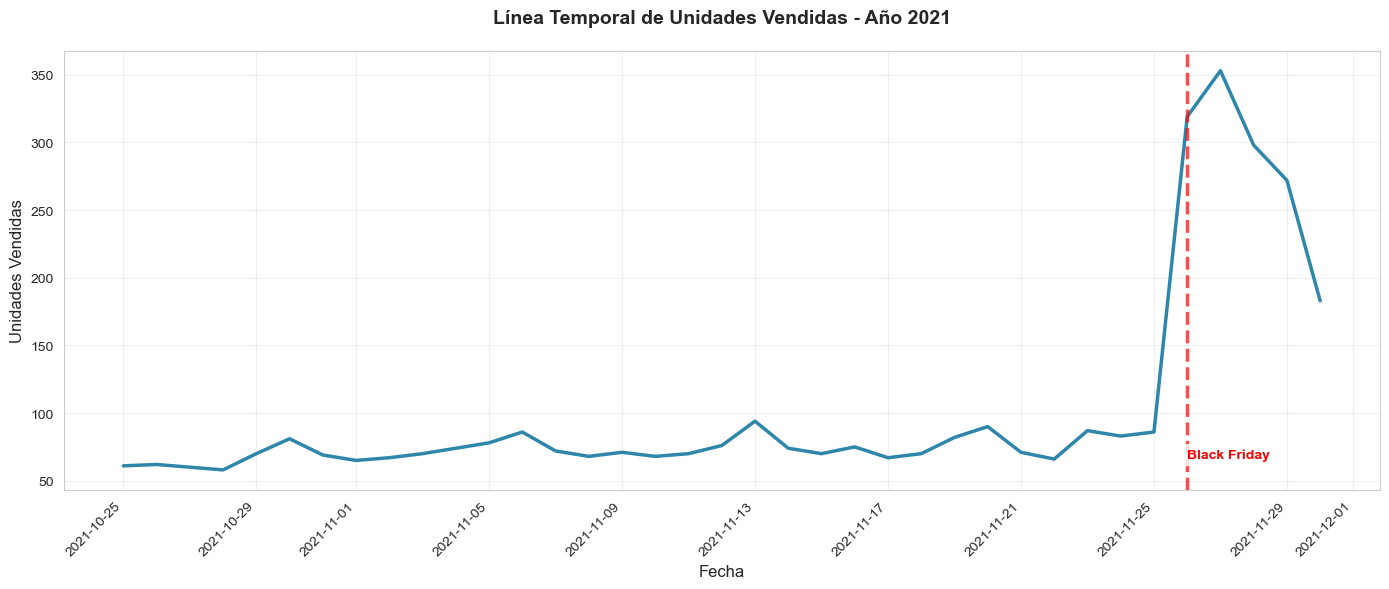

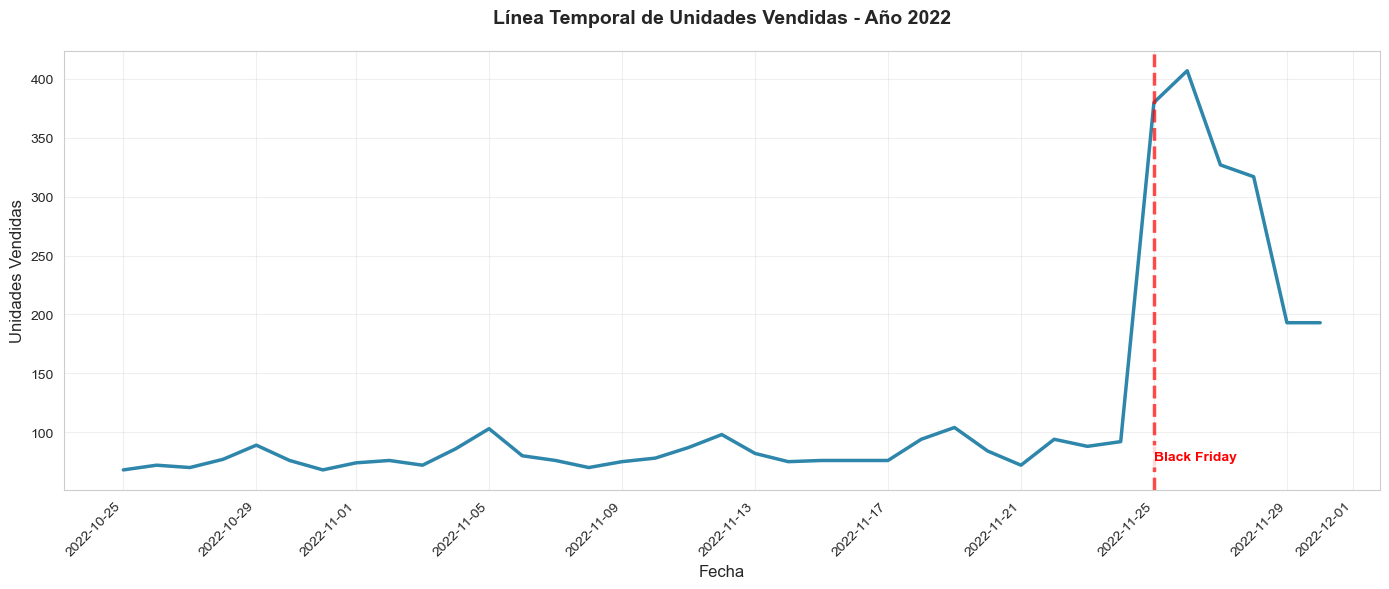

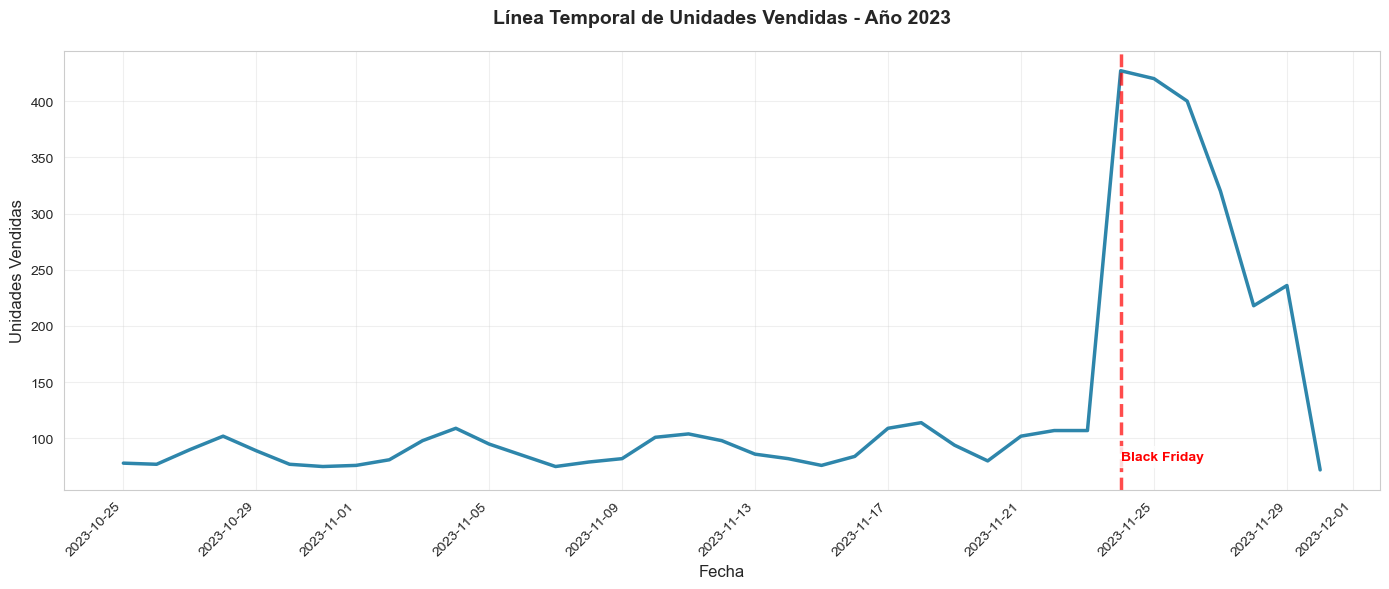

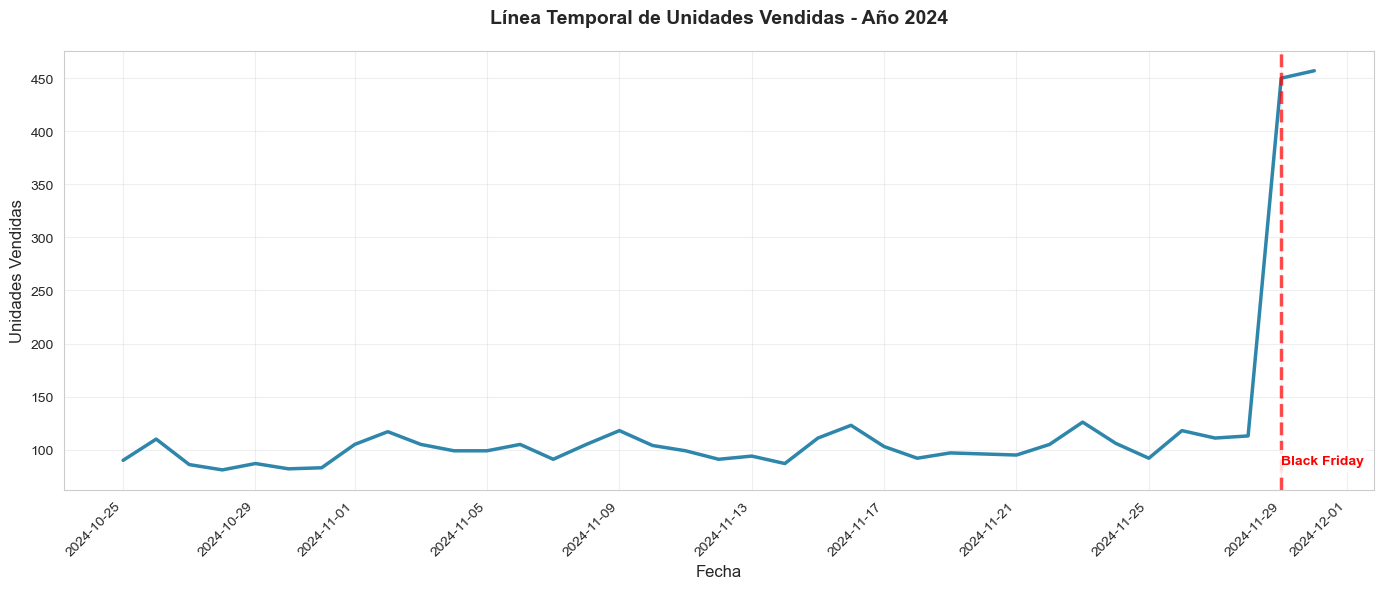

In [15]:
# Agregar datos diarios de unidades vendidas
df_daily = df.groupby('fecha').agg({
    'unidades_vendidas': 'sum',
    'ingresos': 'sum',
    'año': 'first'
}).reset_index()

# Crear gráficos de líneas temporales por año
años_unicos = sorted(df['año'].unique())

for año in años_unicos:
    df_año = df_daily[df_daily['año'] == año].copy()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Gráfico de línea con seaborn
    sns.lineplot(data=df_año, x='fecha', y='unidades_vendidas', 
                 linewidth=2.5, color='#2E86AB', ax=ax)
    
    # Marcar Black Friday
    bf_año = [bf for bf in black_friday_dates if bf.year == año]
    for bf_date in bf_año:
        ax.axvline(x=bf_date, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
        ax.text(bf_date, ax.get_ylim()[1]*0.2, 'Black Friday', 
               rotation=0, verticalalignment='top', horizontalalignment='left',
               fontsize=10, color='red', fontweight='bold', 
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(f'Línea Temporal de Unidades Vendidas - Año {año}', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Fecha', fontsize=12)
    ax.set_ylabel('Unidades Vendidas', fontsize=12)
    
    # Rotar y alinear las fechas del eje x para mejor legibilidad
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Suma de Unidades Vendidas por Día de la Semana

C:\Users\diego\AppData\Local\Temp\ipykernel_29188\4095322509.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dia_semana, x='día_semana', y='unidades_vendidas',
C:\Users\diego\AppData\Local\Temp\ipykernel_29188\4095322509.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],


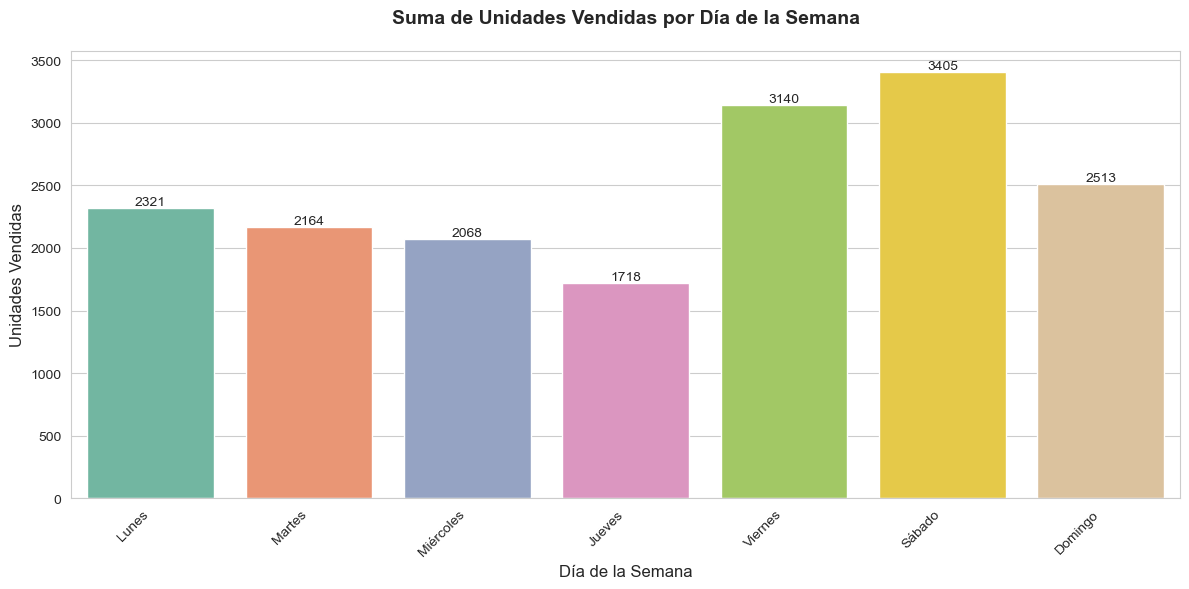

In [16]:
# Agrupar por día de la semana
día_semana_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_dia_semana = df.groupby('día_semana').agg({
    'unidades_vendidas': 'sum'
}).reset_index()

# Reordenar según el orden de los días
df_dia_semana['día_semana'] = pd.Categorical(df_dia_semana['día_semana'], 
                                              categories=día_semana_orden, ordered=True)
df_dia_semana = df_dia_semana.sort_values('día_semana')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_dia_semana, x='día_semana', y='unidades_vendidas', 
            palette='Set2', ax=ax)

ax.set_title('Suma de Unidades Vendidas por Día de la Semana', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Día de la Semana', fontsize=12)
ax.set_ylabel('Unidades Vendidas', fontsize=12)
ax.set_xticklabels(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],
                   rotation=45, ha='right')
ax.tick_params(axis='x', rotation=45)

# Agregar valores en las barras
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_29188\1692853408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='día_semana', y='unidades_vendidas',
C:\Users\diego\AppData\Local\Temp\ipykernel_29188\1692853408.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],


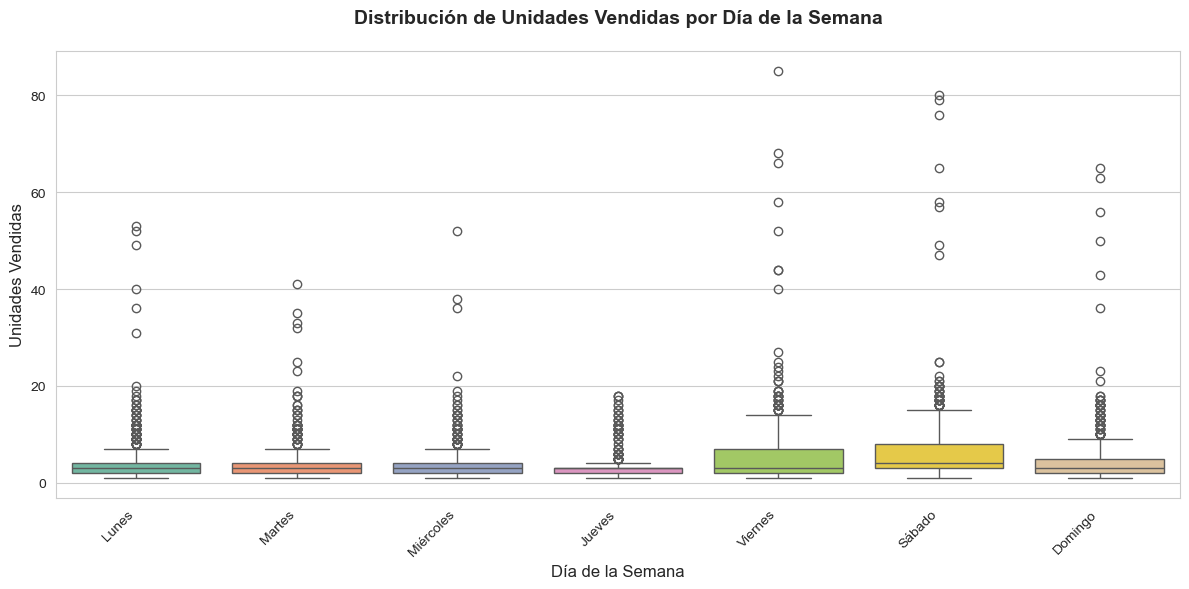

In [17]:
# Agrupar por día de la semana y preparar el orden
día_semana_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['día_semana'] = pd.Categorical(df['día_semana'], categories=día_semana_orden, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='día_semana', y='unidades_vendidas',
            palette='Set2', ax=ax)

ax.set_title('Distribución de Unidades Vendidas por Día de la Semana',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Día de la Semana', fontsize=12)
ax.set_ylabel('Unidades Vendidas', fontsize=12)
ax.set_xticklabels(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],
                   rotation=45, ha='right')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
día_semana_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_dia_semana = df.groupby('día_semana').agg({
    'unidades_vendidas': 'sum'
}).reset_index()



### Suma de Unidades Vendidas por Categoría

C:\Users\diego\AppData\Local\Temp\ipykernel_29188\1769098053.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_categoria, x='categoria', y='unidades_vendidas',
C:\Users\diego\AppData\Local\Temp\ipykernel_29188\1769098053.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


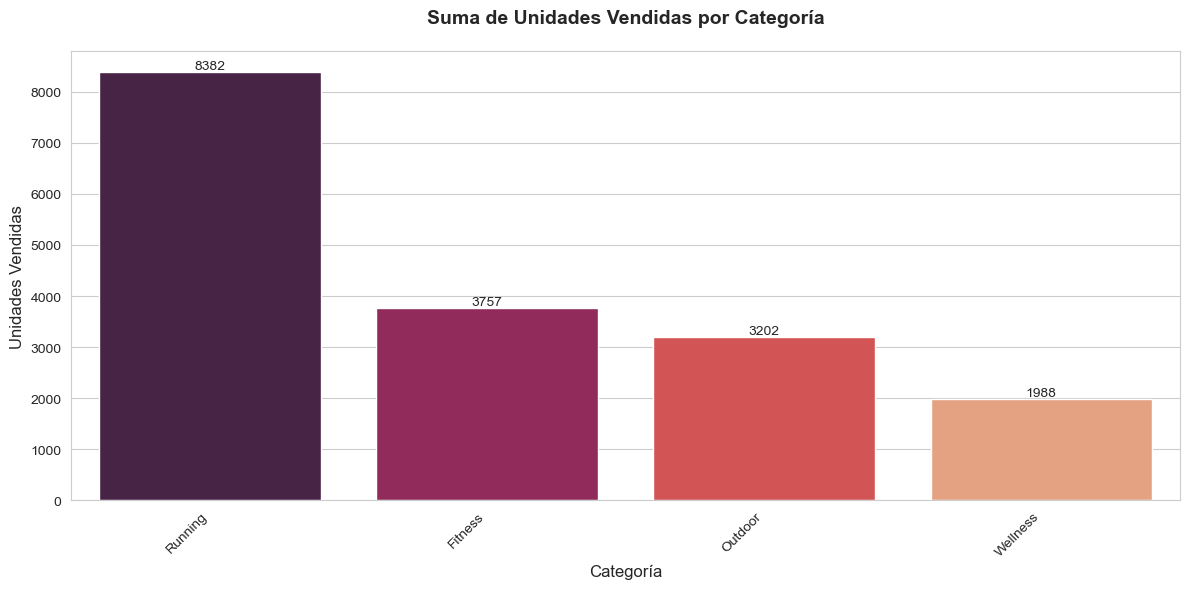

In [18]:
# Agrupar por categoría
df_categoria = df.groupby('categoria').agg({
    'unidades_vendidas': 'sum'
}).reset_index().sort_values('unidades_vendidas', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_categoria, x='categoria', y='unidades_vendidas', 
            palette='rocket', ax=ax)

ax.set_title('Suma de Unidades Vendidas por Categoría', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Unidades Vendidas', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Agregar valores en las barras
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

### Suma de Unidades Vendidas por Subcategoría

C:\Users\diego\AppData\Local\Temp\ipykernel_29188\239467393.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_subcategoria, x='unidades_vendidas', y='subcategoria',


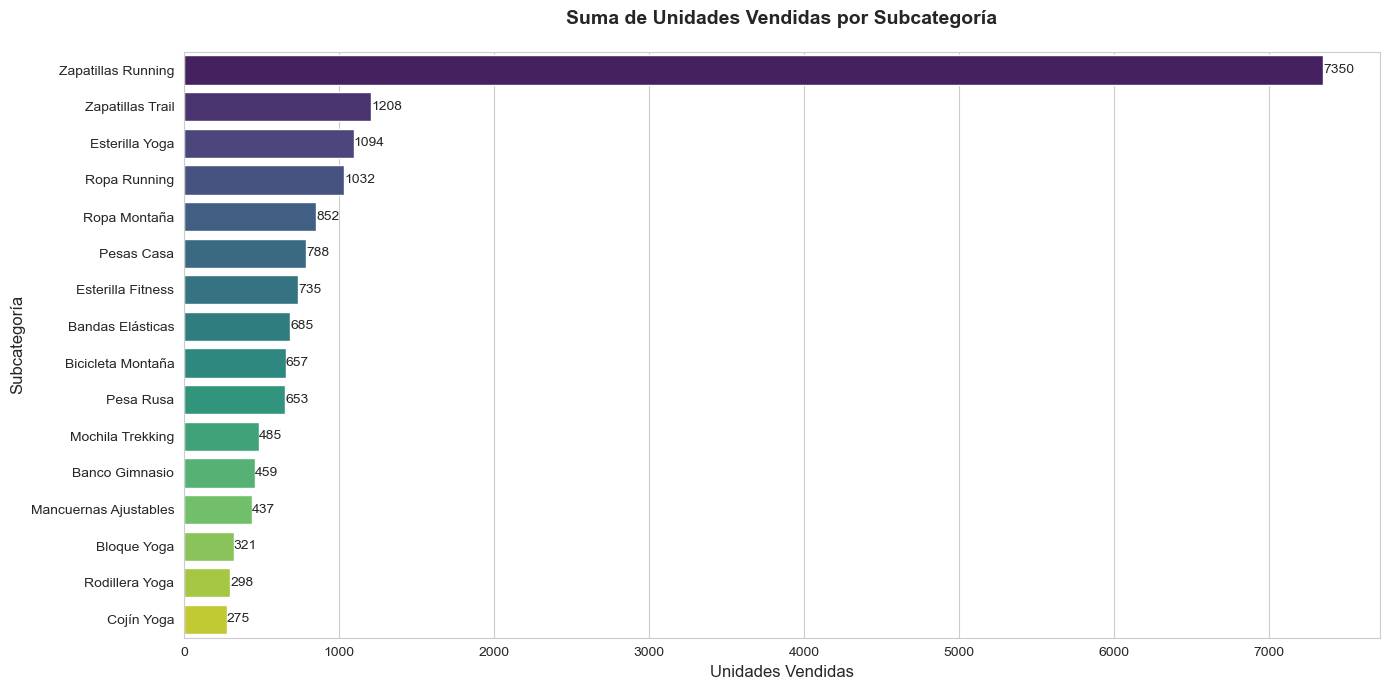

In [19]:
# Agrupar por subcategoría
df_subcategoria = df.groupby('subcategoria').agg({
    'unidades_vendidas': 'sum'
}).reset_index().sort_values('unidades_vendidas', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=df_subcategoria, x='unidades_vendidas', y='subcategoria', 
            palette='viridis', ax=ax)

ax.set_title('Suma de Unidades Vendidas por Subcategoría', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Unidades Vendidas', fontsize=12)
ax.set_ylabel('Subcategoría', fontsize=12)

# Agregar valores en las barras
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

### Top 15 Productos por Unidades Vendidas

C:\Users\diego\AppData\Local\Temp\ipykernel_29188\1692347242.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


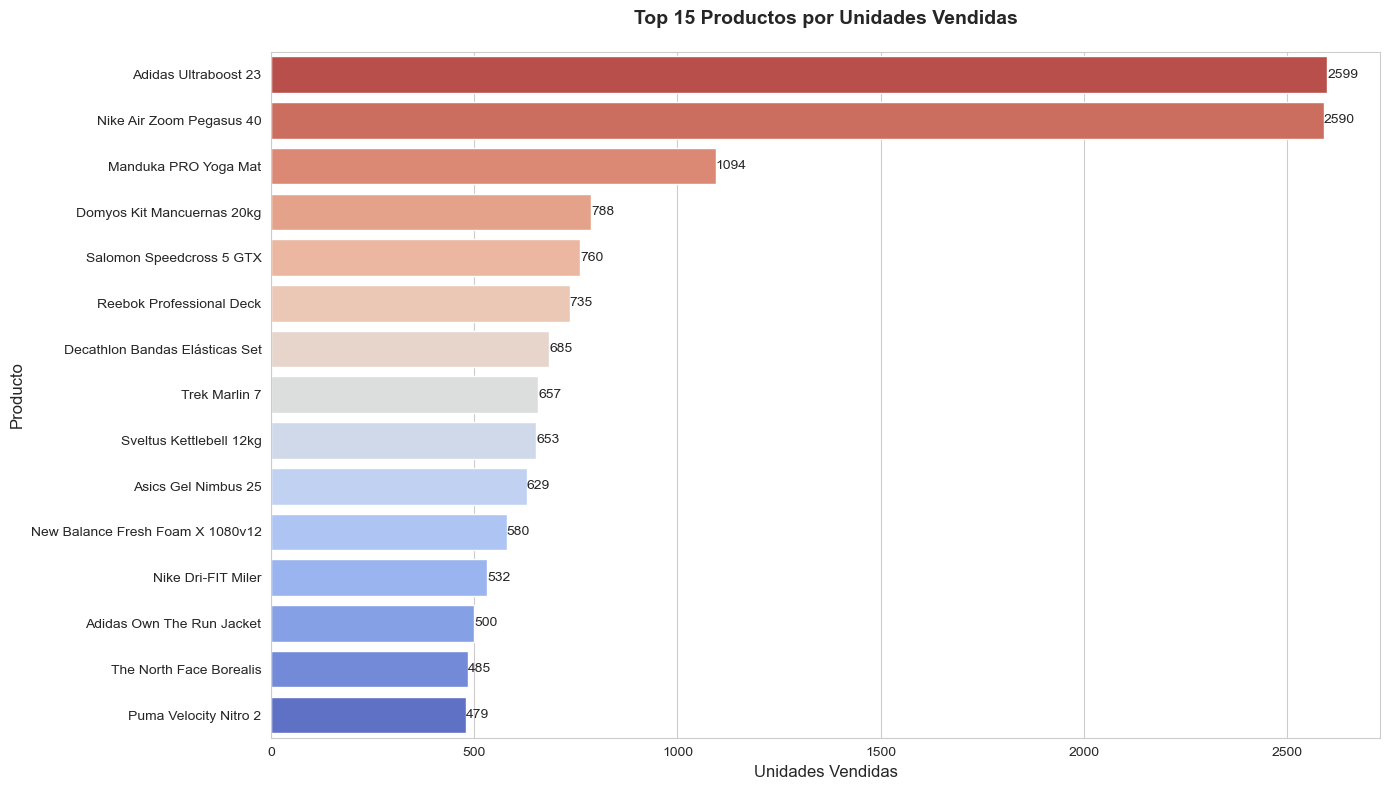

In [20]:
# Agrupar por producto
df_productos = df.groupby('nombre').agg({
    'unidades_vendidas': 'sum',
    'ingresos': 'sum'
}).reset_index().sort_values('unidades_vendidas', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=df_productos,
    x='unidades_vendidas',
    y='nombre',
    palette=sns.color_palette("coolwarm_r", n_colors=len(df_productos)),
    ax=ax
)

ax.set_title('Top 15 Productos por Unidades Vendidas', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Unidades Vendidas', fontsize=12)
ax.set_ylabel('Producto', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()

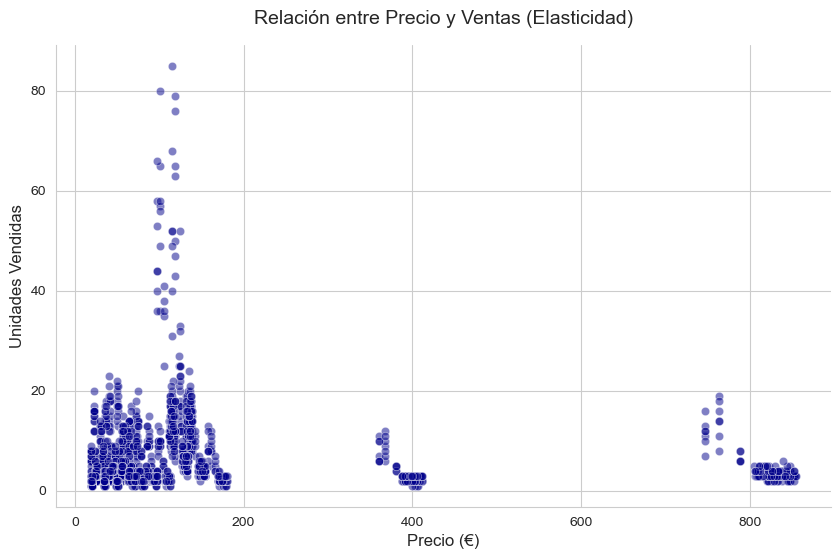

In [21]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creamos el scatter plot
# Usamos alpha=0.5 para dar transparencia a los puntos y ver dónde hay más concentración
sns.scatterplot(
    data=df, 
    x='precio_venta', # Asegúrate de que el nombre coincide con tu columna (ej. 'precio_final' o 'precio')
    y='unidades_vendidas', 
    alpha=0.5, 
    color='darkblue'
)

# Añadimos un título y etiquetas claras
plt.title('Relación entre Precio y Ventas (Elasticidad)', fontsize=14, pad=15)
plt.xlabel('Precio (€)', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)

# Quitamos los bordes superior y derecho para un estilo más limpio
sns.despine()

# Mostramos el gráfico
plt.show()

### Análisis de Densidad de Distribución de Precios (Nuestros vs Competencia)

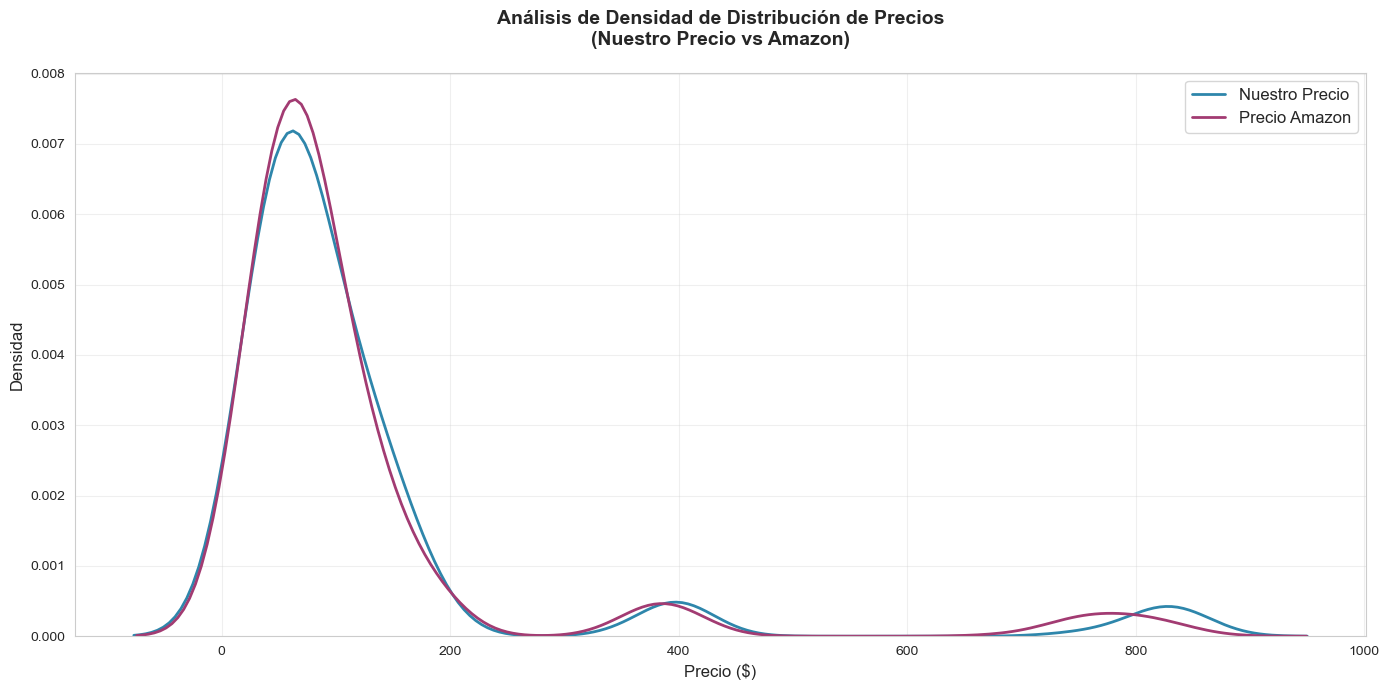


COMPARATIVA DE PRECIOS - ESTADÍSTICAS DESCRIPTIVAS
       Nuestro Precio  Precio Amazon
count     3552.000000    3552.000000
mean       121.816546     118.623407
std        164.017963     156.095628
min         19.000000      16.850000
25%         47.212500      47.117500
50%         71.810000      73.180000
75%        118.220000     114.342500
max        854.220000     858.350000

Diferencia Promedio (Nuestro - Amazon):........... $3.19
Diferencia Máxima (Nuestro - Amazon):............. $172.80
Diferencia Mínima (Nuestro - Amazon):............. $-91.57
Desv. Estándar de Diferencia:..................... $15.92


In [22]:
# Análisis de densidad de precios
fig, ax = plt.subplots(figsize=(14, 7))

# Gráfico de densidad para nuestro precio de venta
sns.kdeplot(data=df, x='precio_venta', label='Nuestro Precio', 
            fill=False, alpha=1, linewidth=2, ax=ax, color='#2E86AB')

# Gráfico de densidad para el precio de Amazon
sns.kdeplot(data=df, x='Amazon', label='Precio Amazon', 
            fill=False, alpha=1, linewidth=2, ax=ax, color='#A23B72')

ax.set_title('Análisis de Densidad de Distribución de Precios\n(Nuestro Precio vs Amazon)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Precio ($)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas comparativas de precios
print("\n" + "="*60)
print("COMPARATIVA DE PRECIOS - ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)

stats_precios = pd.DataFrame({
    'Nuestro Precio': df['precio_venta'].describe(),
    'Precio Amazon': df['Amazon'].describe()
})

print(stats_precios)

# Calcular la diferencia promedio
df['diferencia_precio'] = df['precio_venta'] - df['Amazon']
print(f"\n{'Diferencia Promedio (Nuestro - Amazon):':.<50} ${df['diferencia_precio'].mean():.2f}")
print(f"{'Diferencia Máxima (Nuestro - Amazon):':.<50} ${df['diferencia_precio'].max():.2f}")
print(f"{'Diferencia Mínima (Nuestro - Amazon):':.<50} ${df['diferencia_precio'].min():.2f}")
print(f"{'Desv. Estándar de Diferencia:':.<50} ${df['diferencia_precio'].std():.2f}")

# **Cración de variables temporales**

In [23]:
# ============================================================================
# CREACIÓN DE VARIABLES TEMPORALES Y DE CALENDARIO - ESPAÑA
# ============================================================================

# Obtener días festivos en España
es_holidays = holidays.Spain()

# Variables de fecha básicas
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['día_mes'] = df['fecha'].dt.day
df['día_semana'] = df['fecha'].dt.day_name()
df['día_semana_num'] = df['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo

# Variables booleanas útiles
df['es_fin_semana'] = df['día_semana_num'].isin([5, 6])  # Sábado y Domingo
df['es_lunes'] = (df['día_semana_num'] == 0)
df['es_martes'] = (df['día_semana_num'] == 1)
df['es_miércoles'] = (df['día_semana_num'] == 2)
df['es_jueves'] = (df['día_semana_num'] == 3)
df['es_viernes'] = (df['día_semana_num'] == 4)
df['es_sabado'] = (df['día_semana_num'] == 5)
df['es_domingo'] = (df['día_semana_num'] == 6)

# Variables de festivos (España)
df['es_festivo'] = df['fecha'].apply(lambda x: True if x in es_holidays else False)
df['nombre_festivo'] = df['fecha'].apply(lambda x: es_holidays.get(x, None))

# Variables de eventos comerciales específicos
# Black Friday: último viernes de noviembre
def es_black_friday(fecha):
    if fecha.month != 11:
        return False
    # Obtener el último viernes de noviembre
    ultimo_dia_nov = pd.Timestamp(fecha.year, 11, 30)
    # Encontrar el último viernes
    dias_desde_viernes = (ultimo_dia_nov.dayofweek - 4) % 7 # Calcula cuántos días han pasado desde el último viernes
    ultimo_viernes = ultimo_dia_nov - pd.Timedelta(days=dias_desde_viernes)
    return True if fecha.date() == ultimo_viernes.date() else False

# Cyber Monday: primer lunes de diciembre (o algunos lo consideran 4 días después de Black Friday)
def es_cyber_monday(fecha):
    if fecha.month != 11 and fecha.month != 12:
        return False
    # Black Friday es el último viernes de noviembre
    # Cyber Monday es el siguiente lunes
    if fecha.month == 11:
        ultimo_dia_nov = pd.Timestamp(fecha.year, 11, 30)
        dias_desde_viernes = (ultimo_dia_nov.dayofweek - 4) % 7
        ultimo_viernes = ultimo_dia_nov - pd.Timedelta(days=dias_desde_viernes)
        cyber_monday = ultimo_viernes + pd.Timedelta(days=3)  # 3 días después del viernes
    else:  # Diciembre
        # Alternativamente, Cyber Monday es el primer lunes de diciembre
        primer_dia_dic = pd.Timestamp(fecha.year, 12, 1)
        dias_hasta_lunes = (7 - primer_dia_dic.dayofweek) % 7
        if dias_hasta_lunes == 0 and primer_dia_dic.dayofweek == 0:
            cyber_monday = primer_dia_dic
        else:
            cyber_monday = primer_dia_dic + pd.Timedelta(days=dias_hasta_lunes if dias_hasta_lunes != 0 else 7)
        return True if fecha.date() == cyber_monday.date() else False
    
    return True if fecha.date() == cyber_monday.date() else False

df['es_black_friday'] = df['fecha'].apply(es_black_friday)
df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday)

# Variables de períodos especiales
df['es_temporada_navidad'] = ((df['mes'] == 11) | (df['mes'] == 12))
df['es_inicio_año'] = df['mes'].isin([1, 2])  # Enero y Febrero
df['es_verano'] = df['mes'].isin([6, 7, 8])  # Junio, Julio, Agosto
df['es_cuarentena_pascua'] = df['mes'].isin([3, 4])  # Marzo y Abril (aprox. Semana Santa)

# Número de semana del año
df['num_semana'] = df['fecha'].dt.isocalendar().week
df['trimestre'] = df['fecha'].dt.quarter

# Número de días desde el inicio del año
df['día_año'] = df['fecha'].dt.dayofyear

# Días restantes para fin de año
df['días_hasta_fin_año'] = 365 - df['día_año']
df.loc[df['año'] % 4 == 0, 'días_hasta_fin_año'] = 366 - df['día_año']

# Variable de si es mes con 31 días
df['mes_tiene_31_dias'] = df['mes'].isin([1, 3, 5, 7, 8, 10, 12])

# Variable de días transcurridos desde inicio del mes
df['día_en_mes'] = df['día_mes']

# Variable: es próximo al fin de mes (últimos 3 días)
df['es_fin_mes'] = (df['día_mes'] >= 20)

# Variable: es inicio de mes (primeros 10 días)
df['es_inicio_mes'] = (df['día_mes'] <= 10)

# Mostrar resumen de las nuevas variables
print("="*80)
print("VARIABLES TEMPORALES CREADAS EXITOSAMENTE")
print("="*80)
print(f"\nForma del dataframe: {df.shape}")
print(f"\nNuevas columnas agregadas:")
nuevas_cols = ['año', 'mes', 'día_mes', 'día_semana', 'día_semana_num', 
               'es_fin_semana', 'es_lunes', 'es_martes', 'es_miércoles', 'es_jueves', 'es_viernes', 'es_sabado', 'es_domingo',
               'es_festivo', 'nombre_festivo', 'es_black_friday', 'es_cyber_monday',
               'es_temporada_navidad', 'es_inicio_año', 'es_verano', 'es_cuarentena_pascua',
               'num_semana', 'trimestre', 'día_año', 'días_hasta_fin_año',
               'mes_tiene_31_dias', 'día_en_mes', 'es_fin_mes', 'es_inicio_mes']

for col in nuevas_cols:
    if col in df.columns:
        print(f"  ✓ {col}")

print(f"\nMuestra de variables para un registro:")
print(df[nuevas_cols].head(1).T) # el .T hace que se muestre en formato vertical para mejor legibilidad

print("\n" + "="*80)
print("ESTADÍSTICAS DE VARIABLES BOOLEANAS")
print("="*80)
bool_cols = ['es_fin_semana', 'es_festivo', 'es_black_friday', 'es_cyber_monday',
             'es_temporada_navidad', 'es_inicio_año', 'es_verano', 'es_cuarentena_pascua',
             'es_fin_mes', 'es_inicio_mes', 'es_lunes', 'es_martes', 'es_miércoles', 'es_jueves', 'es_viernes', 'es_sabado', 'es_domingo']

for col in bool_cols:
    if col in df.columns:
        count_true = df[col].sum()
        porcentaje = (count_true / len(df) * 100)
        print(f"{col:.<45} {int(count_true):>6} registros ({porcentaje:>5.2f}%)") 

print("\n" + "="*80)
print("FESTIVOS DETECTADOS EN EL PERÍODO")
print("="*80)
festivos_en_datos = df[df['es_festivo']][['fecha', 'nombre_festivo']].drop_duplicates().sort_values('fecha')
if len(festivos_en_datos) > 0:
    print(festivos_en_datos.to_string(index=False))
else:
    print("No se detectaron festivos en el período")

print("\n" + "="*80)

VARIABLES TEMPORALES CREADAS EXITOSAMENTE

Forma del dataframe: (3552, 43)

Nuevas columnas agregadas:
  ✓ año
  ✓ mes
  ✓ día_mes
  ✓ día_semana
  ✓ día_semana_num
  ✓ es_fin_semana
  ✓ es_lunes
  ✓ es_martes
  ✓ es_miércoles
  ✓ es_jueves
  ✓ es_viernes
  ✓ es_sabado
  ✓ es_domingo
  ✓ es_festivo
  ✓ nombre_festivo
  ✓ es_black_friday
  ✓ es_cyber_monday
  ✓ es_temporada_navidad
  ✓ es_inicio_año
  ✓ es_verano
  ✓ es_cuarentena_pascua
  ✓ num_semana
  ✓ trimestre
  ✓ día_año
  ✓ días_hasta_fin_año
  ✓ mes_tiene_31_dias
  ✓ día_en_mes
  ✓ es_fin_mes
  ✓ es_inicio_mes

Muestra de variables para un registro:
                           0
año                     2021
mes                       10
día_mes                   25
día_semana            Monday
día_semana_num             0
es_fin_semana          False
es_lunes                True
es_martes              False
es_miércoles           False
es_jueves              False
es_viernes             False
es_sabado              False
es_domin

In [24]:
df[df['mes'] == 10].head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_verano,es_cuarentena_pascua,num_semana,trimestre,día_año,días_hasta_fin_año,mes_tiene_31_dias,día_en_mes,es_fin_mes,es_inicio_mes
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115.0,True,6,118.36,710.16,...,False,False,43,4,298,67,True,25,True,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135.0,True,10,136.82,1368.20,...,False,False,43,4,298,67,True,25,True,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85.0,False,2,84.93,169.86,...,False,False,43,4,298,67,True,25,True,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75.0,False,2,75.42,150.84,...,False,False,43,4,298,67,True,25,True,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35.0,False,2,35.87,71.74,...,False,False,43,4,298,67,True,25,True,False


In [25]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_verano,es_cuarentena_pascua,num_semana,trimestre,día_año,días_hasta_fin_año,mes_tiene_31_dias,día_en_mes,es_fin_mes,es_inicio_mes
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115.0,True,6,118.36,710.16,...,False,False,43,4,298,67,True,25,True,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135.0,True,10,136.82,1368.20,...,False,False,43,4,298,67,True,25,True,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85.0,False,2,84.93,169.86,...,False,False,43,4,298,67,True,25,True,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75.0,False,2,75.42,150.84,...,False,False,43,4,298,67,True,25,True,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35.0,False,2,35.87,71.74,...,False,False,43,4,298,67,True,25,True,False


In [26]:
df.shape

(3552, 43)

In [27]:
# ============================================================================
# RECONSTRUIR DATAFRAME SIN ELIMINAR NOMBRE_FESTIVO
# ============================================================================
# Recargar y reconstruir para no tener problemas con eliminaciones anteriores

# Cargar datos originales
df_ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
df_competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

# Convertir fechas
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'])

# Integrar
df = pd.merge(df_ventas, df_competencia, how='inner', on=['fecha', 'producto_id'])

# Reordenar y crear variables temporales sin nombre_festivo en el dropna posterior
df = df.sort_values(['fecha', 'producto_id']).reset_index(drop=True)

# Obtener días festivos en España
es_holidays = holidays.Spain()

# Variables de fecha básicas
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['día_mes'] = df['fecha'].dt.day
df['día_semana'] = df['fecha'].dt.day_name()
df['día_semana_num'] = df['fecha'].dt.dayofweek

# Variables booleanas
df['es_fin_semana'] = df['día_semana_num'].isin([5, 6])
df['es_lunes'] = (df['día_semana_num'] == 0)
df['es_viernes'] = (df['día_semana_num'] == 4)
df['es_sabado'] = (df['día_semana_num'] == 5)
df['es_domingo'] = (df['día_semana_num'] == 6)

# Variables de festivos (España)
df['es_festivo'] = df['fecha'].apply(lambda x: True if x in es_holidays else False)
df['nombre_festivo'] = df['fecha'].apply(lambda x: es_holidays.get(x, None))

# Black Friday y Cyber Monday
def es_black_friday(fecha):
    if fecha.month != 11:
        return False
    ultimo_dia_nov = pd.Timestamp(fecha.year, 11, 30)
    dias_desde_viernes = (ultimo_dia_nov.dayofweek - 4) % 7
    ultimo_viernes = ultimo_dia_nov - pd.Timedelta(days=dias_desde_viernes)
    return True if fecha.date() == ultimo_viernes.date() else False

def es_cyber_monday(fecha):
    if fecha.month != 11 and fecha.month != 12:
        return False
    if fecha.month == 11:
        ultimo_dia_nov = pd.Timestamp(fecha.year, 11, 30)
        dias_desde_viernes = (ultimo_dia_nov.dayofweek - 4) % 7
        ultimo_viernes = ultimo_dia_nov - pd.Timedelta(days=dias_desde_viernes)
        cyber_monday = ultimo_viernes + pd.Timedelta(days=3)
    else:
        primer_dia_dic = pd.Timestamp(fecha.year, 12, 1)
        dias_hasta_lunes = (7 - primer_dia_dic.dayofweek) % 7
        if dias_hasta_lunes == 0 and primer_dia_dic.dayofweek == 0:
            cyber_monday = primer_dia_dic
        else:
            cyber_monday = primer_dia_dic + pd.Timedelta(days=dias_hasta_lunes if dias_hasta_lunes != 0 else 7)
        return True if fecha.date() == cyber_monday.date() else False
    return True if fecha.date() == cyber_monday.date() else False

df['es_black_friday'] = df['fecha'].apply(es_black_friday)
df['es_cyber_monday'] = df['fecha'].apply(es_cyber_monday)

# Variables de períodos especiales
df['es_temporada_navidad'] = ((df['mes'] == 11) | (df['mes'] == 12))
df['es_inicio_año'] = df['mes'].isin([1, 2])
df['es_verano'] = df['mes'].isin([6, 7, 8])
df['es_cuarentena_pascua'] = df['mes'].isin([3, 4])

# Variables de calendario
df['num_semana'] = df['fecha'].dt.isocalendar().week
df['trimestre'] = df['fecha'].dt.quarter
df['día_año'] = df['fecha'].dt.dayofyear
df['días_hasta_fin_año'] = 365 - df['día_año']
df.loc[df['año'] % 4 == 0, 'días_hasta_fin_año'] = 366 - df['día_año']
df['mes_tiene_31_dias'] = df['mes'].isin([1, 3, 5, 7, 8, 10, 12])
df['día_en_mes'] = df['día_mes']
df['es_fin_mes'] = (df['día_mes'] >= 28)
df['es_inicio_mes'] = (df['día_mes'] <= 3)

# Eliminar nulos solo en columnas que NO sean nombre_festivo
cols_para_eliminar_nulos = [col for col in df.columns if col != 'nombre_festivo' and col != 'día_semana']
df = df.dropna(subset=cols_para_eliminar_nulos)

print(f"Dataframe reconstruido: {df.shape}")
print(f"Registros por año:")
for año in sorted(df['año'].unique()):
    print(f"  Año {año}: {len(df[df['año'] == año])} registros")


Dataframe reconstruido: (3552, 39)
Registros por año:
  Año 2021: 888 registros
  Año 2022: 888 registros
  Año 2023: 888 registros
  Año 2024: 888 registros


In [28]:
# ============================================================================
# CREACIÓN DE LAGS Y MEDIA MÓVIL — POR PRODUCTO, SIN LEAKAGE
# ============================================================================

print("="*80)
print("CREACIÓN DE VARIABLES REZAGADAS (LAGS) Y MEDIA MÓVIL")
print("="*80)

# Ordenar por producto y luego por fecha: así el shift() avanza dentro
# de la serie temporal de CADA producto, nunca cruza a otro producto
df = df.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

# Lags: groupby garantiza que el shift(n) coge el valor de ese MISMO
# producto n días antes, nunca de otro producto
for lag in range(1, 8):
    df[f'lag_{lag}_unidades_vendidas'] = (
        df.groupby('producto_id')['unidades_vendidas'].shift(lag)
    )

# Media móvil de 7 días: shift(1) ANTES del rolling, para que el día
# actual nunca entre en su propio promedio
df['media_movil_7_unidades_vendidas'] = (
    df.groupby('producto_id')['unidades_vendidas']
      .transform(lambda s: s.shift(1).rolling(window=7, min_periods=1).mean())
)

lag_cols = [f'lag_{i}_unidades_vendidas' for i in range(1, 8)]
lag_cols.append('media_movil_7_unidades_vendidas')

registros_antes = len(df)
df = df.dropna(subset=lag_cols)
registros_despues = len(df)

print(f"Registros antes: {registros_antes}")
print(f"Registros después de eliminar nulos en lags: {registros_despues}")
print(f"Eliminados: {registros_antes - registros_despues} "
      f"({(registros_antes - registros_despues) / registros_antes * 100:.2f}%)")

for año in sorted(df['año'].unique()):
    print(f"  Año {año}: {len(df[df['año'] == año])} registros")

print("\n" + "="*80)
print("RESUMEN FINAL")
print("="*80)
print(f"Forma final del dataframe: {df.shape}")
print(f"Total de columnas: {df.shape[1]}")
print(f"Total de registros: {df.shape[0]}")

# Verificar que no hay nulos en las variables de lags
print(f"\nVerificación de nulos en variables de lags:")
for col in lag_cols:
    count_nulos = df[col].isnull().sum()
    print(f"  {col}: {count_nulos} nulos")

# Mostrar tipos de datos de los nuevos lags
print(f"\nTipos de datos de las nuevas variables:")
for col in lag_cols:
    print(f"  {col}: {df[col].dtype}")

print("\n✓ Lags y media móvil creados correctamente")
print("✓ Nulos en lags eliminados correctamente")
print("✓ Dataframe listo para modelamiento")
print("\n" + "="*80)


CREACIÓN DE VARIABLES REZAGADAS (LAGS) Y MEDIA MÓVIL
Registros antes: 3552
Registros después de eliminar nulos en lags: 3384
Eliminados: 168 (4.73%)
  Año 2021: 720 registros
  Año 2022: 888 registros
  Año 2023: 888 registros
  Año 2024: 888 registros

RESUMEN FINAL
Forma final del dataframe: (3384, 47)
Total de columnas: 47
Total de registros: 3384

Verificación de nulos en variables de lags:
  lag_1_unidades_vendidas: 0 nulos
  lag_2_unidades_vendidas: 0 nulos
  lag_3_unidades_vendidas: 0 nulos
  lag_4_unidades_vendidas: 0 nulos
  lag_5_unidades_vendidas: 0 nulos
  lag_6_unidades_vendidas: 0 nulos
  lag_7_unidades_vendidas: 0 nulos
  media_movil_7_unidades_vendidas: 0 nulos

Tipos de datos de las nuevas variables:
  lag_1_unidades_vendidas: float64
  lag_2_unidades_vendidas: float64
  lag_3_unidades_vendidas: float64
  lag_4_unidades_vendidas: float64
  lag_5_unidades_vendidas: float64
  lag_6_unidades_vendidas: float64
  lag_7_unidades_vendidas: float64
  media_movil_7_unidades_ven

In [29]:
df.groupby('año').size()

año
2021    720
2022    888
2023    888
2024    888
dtype: int64

**Creación de variable porcentual**

In [30]:
n_ceros = df['precio_base'].eq(0).sum()
print(n_ceros) #comprobamos que no hay precios base en 0, ya que eso podría afectar el análisis de elasticidad

0


In [31]:
# ============================================================================
# CREACIÓN DE VARIABLE DESCUENTO PORCENTUAL
# ============================================================================

print("="*80)
print("CREACIÓN DE VARIABLE: DESCUENTO PORCENTAJE")
print("="*80)

# Crear variable de descuento porcentual
# Fórmula: ((precio_venta - precio_base) / precio_base) * 100
df['descuento_porcentaje'] = ((df['precio_base'] - df['precio_venta']) / df['precio_base']) * 100

print("\n✓ Variable 'descuento_porcentaje' creada exitosamente")

# Estadísticas descriptivas del descuento
print("\n" + "="*80)
print("ESTADÍSTICAS DEL DESCUENTO PORCENTAJE")
print("="*80)

print(f"\nDescriptivas generales:")
print(df['descuento_porcentaje'].describe())

print(f"\n{'Descuento Mínimo (%)':.<45} {df['descuento_porcentaje'].min():>10.2f}%")
print(f"{'Descuento Máximo (%)':.<45} {df['descuento_porcentaje'].max():>10.2f}%")
print(f"{'Descuento Promedio (%)':.<45} {df['descuento_porcentaje'].mean():>10.2f}%")
print(f"{'Descuento Mediana (%)':.<45} {df['descuento_porcentaje'].median():>10.2f}%")
print(f"{'Desviación Estándar (%)':.<45} {df['descuento_porcentaje'].std():>10.2f}%")

# Análisis de distribución
print(f"\n" + "="*80)
print("DISTRIBUCIÓN DE DESCUENTOS")
print("="*80)

descuento_ranges = [
    ('Sin descuento (0%)', 0, 0),
    ('Descuento bajo (0-5%)', 0, 5),
    ('Descuento medio (5-10%)', 5, 10),
    ('Descuento alto (10-15%)', 10, 15),
    ('Descuento muy alto (>15%)', 15, 100)
]

for label, min_val, max_val in descuento_ranges:
    if min_val == max_val:
        count = (df['descuento_porcentaje'] == min_val).sum()
    else:
        count = ((df['descuento_porcentaje'] > min_val) & (df['descuento_porcentaje'] <= max_val)).sum()
    porcentaje = (count / len(df)) * 100
    print(f"{label:.<45} {int(count):>6} registros ({porcentaje:>5.2f}%)")

# Muestra de datos con la nueva variable
print(f"\n" + "="*80)
print("MUESTRA DE DATOS CON DESCUENTO PORCENTAJE")
print("="*80)

df_muestra = df[['fecha', 'nombre', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head(10)
print("\n" + df_muestra.to_string(index=False))

# Correlación con unidades vendidas
print(f"\n" + "="*80)
print("ANÁLISIS DE DESCUENTO VS UNIDADES VENDIDAS")
print("="*80)

correlacion = df['descuento_porcentaje'].corr(df['unidades_vendidas'])
print(f"\nCorrelación entre descuento y unidades vendidas: {correlacion:.4f}")

if correlacion > 0:
    print("→ Correlación POSITIVA: A mayor descuento, mayores ventas (esperado)")
elif correlacion < 0:
    print("→ Correlación NEGATIVA: A mayor descuento, menores ventas (inesperado)")
else:
    print("→ No hay correlación significativa")

print("\n" + "="*80)
print("RESUMEN")
print("="*80)
print(f"Total de registros: {len(df)}")
print(f"Total de columnas: {df.shape[1]}")
print(f"✓ Variable 'descuento_porcentaje' agregada correctamente")
print("\n" + "="*80)


CREACIÓN DE VARIABLE: DESCUENTO PORCENTAJE

✓ Variable 'descuento_porcentaje' creada exitosamente

ESTADÍSTICAS DEL DESCUENTO PORCENTAJE

Descriptivas generales:
count    3384.000000
mean        1.129073
std         3.619174
min        -3.000000
25%        -1.322857
50%         0.434135
75%         2.166867
max        15.000000
Name: descuento_porcentaje, dtype: float64

Descuento Mínimo (%).........................      -3.00%
Descuento Máximo (%).........................      15.00%
Descuento Promedio (%).......................       1.13%
Descuento Mediana (%)........................       0.43%
Desviación Estándar (%)......................       3.62%

DISTRIBUCIÓN DE DESCUENTOS
Sin descuento (0%)...........................      8 registros ( 0.24%)
Descuento bajo (0-5%)........................   1578 registros (46.63%)
Descuento medio (5-10%)......................    208 registros ( 6.15%)
Descuento alto (10-15%)......................    112 registros ( 3.31%)
Descuento muy alto (

**Variable precio competencia**

In [32]:
# ============================================================================
# CREACIÓN DE VARIABLES DE COMPETENCIA Y ELIMINACIÓN DE COLUMNAS REDUNDANTES
# ============================================================================

print("="*80)
print("CREACIÓN DE VARIABLE: PRECIO COMPETENCIA Y RATIO PRECIO")
print("="*80)

# Crear variable precio_competencia como promedio de los competidores
df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

print("\n✓ Variable 'precio_competencia' creada (promedio de Amazon, Decathlon, Deporvillage)")

# Crear variable ratio_precio como nuestro precio_venta / precio_competencia
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia'] # normalizacion del precio frente a la competencia

print("✓ Variable 'ratio_precio' creada (precio_venta / precio_competencia)")

# Estadísticas descriptivas
print("\n" + "="*80)
print("ESTADÍSTICAS DEL PRECIO DE COMPETENCIA")
print("="*80)

print(f"\nPrecio de Competencia (promedio):")
print(df['precio_competencia'].describe())

print(f"\n{'Precio Competencia Mínimo ($)':.<45} ${df['precio_competencia'].min():>10.2f}")
print(f"{'Precio Competencia Máximo ($)':.<45} ${df['precio_competencia'].max():>10.2f}")
print(f"{'Precio Competencia Promedio ($)':.<45} ${df['precio_competencia'].mean():>10.2f}")
print(f"{'Precio Competencia Mediana ($)':.<45} ${df['precio_competencia'].median():>10.2f}")

print(f"\n" + "="*80)
print("ESTADÍSTICAS DEL RATIO PRECIO")
print("="*80)

print(f"\nRatio Precio (Nuestro / Competencia):")
print(df['ratio_precio'].describe())

print(f"\n{'Ratio Precio Mínimo':.<45} {df['ratio_precio'].min():>10.4f}x")
print(f"{'Ratio Precio Máximo':.<45} {df['ratio_precio'].max():>10.4f}x")
print(f"{'Ratio Precio Promedio':.<45} {df['ratio_precio'].mean():>10.4f}x")
print(f"{'Ratio Precio Mediana':.<45} {df['ratio_precio'].median():>10.4f}x")

# Análisis de interpretación del ratio_precio
print(f"\n" + "="*80)
print("INTERPRETACIÓN DEL RATIO PRECIO")
print("="*80)

ratio_ranges = [
    ('Precio MUY inferior (<0.90)', 0, 0.90),
    ('Precio inferior (0.90-0.95)', 0.90, 0.95),
    ('Precio similar (0.95-1.05)', 0.95, 1.05),
    ('Precio superior (1.05-1.10)', 1.05, 1.10),
    ('Precio MUY superior (>1.10)', 1.10, 10)
]

for label, min_val, max_val in ratio_ranges:
    count = ((df['ratio_precio'] >= min_val) & (df['ratio_precio'] < max_val)).sum()
    porcentaje = (count / len(df)) * 100
    print(f"{label:.<45} {int(count):>6} registros ({porcentaje:>5.2f}%)")

# Correlación con unidades vendidas
print(f"\n" + "="*80)
print("ANÁLISIS DE RATIO PRECIO VS UNIDADES VENDIDAS")
print("="*80)

correlacion_ratio = df['ratio_precio'].corr(df['unidades_vendidas'])
print(f"\nCorrelación entre ratio_precio y unidades vendidas: {correlacion_ratio:.4f}")

if correlacion_ratio > 0:
    print("→ Correlación POSITIVA: Precios más altos que competencia correlacionan con más ventas")
elif correlacion_ratio < 0:
    print("→ Correlación NEGATIVA: Precios más bajos que competencia correlacionan con más ventas")
else:
    print("→ No hay correlación significativa")

# Muestra de datos con las nuevas variables
print(f"\n" + "="*80)
print("MUESTRA DE DATOS CON NUEVAS VARIABLES")
print("="*80)

df_muestra = df[['fecha', 'nombre', 'precio_venta', 'Amazon', 'Decathlon', 'Deporvillage', 
                  'precio_competencia', 'ratio_precio']].head(8)
print("\n" + df_muestra.to_string(index=False))

# Eliminar las columnas de competencia individual
print(f"\n" + "="*80)
print("ELIMINACIÓN DE COLUMNAS DE COMPETENCIA INDIVIDUAL")
print("="*80)

cols_a_eliminar = ['Amazon', 'Decathlon', 'Deporvillage', 'precio_venta', 'precio_competencia']
print(f"\nEliminando columnas: {', '.join(cols_a_eliminar)}")

df = df.drop(columns=cols_a_eliminar)

print(f"✓ Columnas eliminadas correctamente")

print(f"\n" + "="*80)
print("RESUMEN FINAL")
print("="*80)
print(f"Total de registros: {len(df)}")
print(f"Total de columnas: {df.shape[1]}")
print(f"✓ Variable 'precio_competencia' agregada")
print(f"✓ Variable 'ratio_precio' agregada")
print(f"✓ Columnas de competencia individual eliminadas")
print(f"\nNuevas variables disponibles:")
print(f"  - precio_competencia: Precio promedio de competidores")
print(f"  - ratio_precio: Nuestro precio / precio promedio competencia")
print("\n" + "="*80)


CREACIÓN DE VARIABLE: PRECIO COMPETENCIA Y RATIO PRECIO

✓ Variable 'precio_competencia' creada (promedio de Amazon, Decathlon, Deporvillage)
✓ Variable 'ratio_precio' creada (precio_venta / precio_competencia)

ESTADÍSTICAS DEL PRECIO DE COMPETENCIA

Precio de Competencia (promedio):
count    3384.000000
mean      116.489246
std       155.269801
min        16.646667
25%        45.559167
50%        70.241667
75%       110.844167
max       884.616667
Name: precio_competencia, dtype: float64

Precio Competencia Mínimo ($)................ $     16.65
Precio Competencia Máximo ($)................ $    884.62
Precio Competencia Promedio ($).............. $    116.49
Precio Competencia Mediana ($)............... $     70.24

ESTADÍSTICAS DEL RATIO PRECIO

Ratio Precio (Nuestro / Competencia):
count    3384.000000
mean        1.034540
std         0.057002
min         0.823112
25%         1.002928
50%         1.031675
75%         1.061326
max         1.303042
Name: ratio_precio, dtype: float64

# **Encoding de variables para el ML**

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 3384 entries, 7 to 3551
Data columns (total 45 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   fecha                            3384 non-null   datetime64[us]
 1   producto_id                      3384 non-null   str           
 2   nombre                           3384 non-null   str           
 3   categoria                        3384 non-null   str           
 4   subcategoria                     3384 non-null   str           
 5   precio_base                      3384 non-null   int64         
 6   es_estrella                      3384 non-null   bool          
 7   unidades_vendidas                3384 non-null   int64         
 8   ingresos                         3384 non-null   float64       
 9   año                              3384 non-null   int32         
 10  mes                              3384 non-null   int32         
 11  día_mes

In [34]:
# Guardar el df en processed
df.to_csv('../data/processed/df.csv', index=False)
print("\n✓ Dataframe final guardado en '../data/processed/df.csv'")


✓ Dataframe final guardado en '../data/processed/df.csv'


# **Machine Learning**

In [35]:
# Dividir el df en train_df (2021-2023) y validation_df (2024) 
train_df = df[df['año'].isin([2021, 2022, 2023])].copy()
validation_df = df[df['año'] == 2024].copy()

print(f"\nTrain set (2021-2023): {train_df.shape[0]} registros")
print(f"Validation set (2024): {validation_df.shape[0]} registros")


Train set (2021-2023): 2496 registros
Validation set (2024): 888 registros


In [36]:
# Código para entrenar un HistGradientBoostingRegressor con parámetros conservadores para evitar el overfitting:
# learning_rate bajo, bastantes árboles, profundidad moderada y regularización. 
# La target es unidades_vendidas, y las predictoras son el resto de variables excepto fecha, ingresos y todas las que sean de tipo object
# Entrenamiento en train_df y validación en validation_df. 
# Cálculo de las métricas típicas de forecasting y comparación con un baseline naive que predice la media de unidades_vendidas del train_df.

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Antes excluíamos nombre/categoria/subcategoria porque eran texto y el modelo
# no las podía usar directamente. Ahora SÍ las dejamos entrar como predictoras:
# el Pipeline las convertirá a one-hot automáticamente en el paso de preprocesado.
# día_semana y nombre_festivo se siguen excluyendo (redundante/demasiado disperso,
# decisión que ya tomamos antes), igual que fecha, ingresos, producto_id y año.
cols_excluir = ['fecha', 'ingresos', 'unidades_vendidas',
                'producto_id', 'día_semana', 'nombre_festivo', 'año']

predictor_vars = [col for col in train_df.columns if col not in cols_excluir]

X_train = train_df[predictor_vars]
y_train = train_df['unidades_vendidas']
X_val = validation_df[predictor_vars]
y_val = validation_df['unidades_vendidas']

# Baseline naive: predecir el valor de 7 días atrás para comparar con el modelo.
mask = y_val != 0
y_pred_naive_seasonal = validation_df['lag_7_unidades_vendidas']
mae_naive_seasonal = mean_absolute_error(y_val, y_pred_naive_seasonal)
mse_naive_seasonal = mean_squared_error(y_val, y_pred_naive_seasonal)
rmse_naive_seasonal = np.sqrt(mse_naive_seasonal)
r2_naive_seasonal = r2_score(y_val, y_pred_naive_seasonal)
mape_naive_seasonal = (abs((y_val[mask] - y_pred_naive_seasonal[mask]) / y_val[mask])).mean() * 100

In [37]:
# ============================================================
# MODELO FINAL: Pipeline (OneHotEncoder + HistGradientBoostingRegressor)
# Walk-forward validation (TimeSeriesSplit) + búsqueda automática
# de hiperparámetros (RandomizedSearchCV)
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import uniform, randint
import numpy as np

# --- 1. Preparar datos, respetando el orden temporal ---
train_df = train_df.sort_values('fecha').reset_index(drop=True)
validation_df = validation_df.sort_values('fecha').reset_index(drop=True)

X_train = train_df[predictor_vars]
y_train = train_df['unidades_vendidas']
X_val = validation_df[predictor_vars]
y_val = validation_df['unidades_vendidas']

# --- 2. Preprocesador: convierte SOLO las 3 columnas categóricas a one-hot,
#         y deja el resto (lags, calendario, precios...) tal cual pasan ---
variables_categoricas = ['nombre', 'categoria', 'subcategoria']

preprocesador = ColumnTransformer(
    transformers=[
        # handle_unknown='ignore' -> si en inferencia apareciera una categoría
        # nunca vista en entrenamiento, no revienta: esa columna queda a 0
        # en vez de lanzar un error. Es la ventaja frente a pd.get_dummies().
        ('categoricas', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         variables_categoricas)
    ],
    remainder='passthrough'  # el resto de columnas (lags, calendario, precios...) sin tocar
)
# Nota: si tu versión de scikit-learn es anterior a la 1.2, cambia
# sparse_output=False por sparse=False (el parámetro se renombró en 1.2).

# --- 3. Modelo base (idéntico al que ya tenías) ---
base_model = HistGradientBoostingRegressor(
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)

# --- 4. Pipeline completo: preprocesado + modelo como un único objeto ---
pipeline_completo = Pipeline([
    ('preprocesado', preprocesador),
    ('modelo', base_model)
])

# --- 5. Esquema de validación walk-forward, SOLO sobre 2021-2023 ---
# 2024 (validation_df) no participa en nada de esto: se reserva intacto
# como test final para no "espiar" el resultado durante el ajuste.
tscv = TimeSeriesSplit(n_splits=5)

# --- 6. Espacio de búsqueda de hiperparámetros ---
# OJO: como el estimador ahora es un Pipeline, cada hiperparámetro hay que
# dirigirlo al paso correcto con el prefijo "modelo__" (así sklearn sabe que
# 'learning_rate' es un parámetro del paso llamado 'modelo', no del 'preprocesado')
param_dist = {
    'modelo__learning_rate': uniform(0.01, 0.19),      # rango: 0.01 - 0.20
    'modelo__max_iter': randint(150, 600),
    'modelo__max_leaf_nodes': randint(15, 63),
    'modelo__max_depth': randint(3, 12),
    'modelo__min_samples_leaf': randint(10, 50),
    'modelo__l2_regularization': uniform(0, 3),
}

search = RandomizedSearchCV(
    estimator=pipeline_completo,   # <- antes era base_model, ahora el pipeline entero
    param_distributions=param_dist,
    n_iter=40,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# --- 7. Búsqueda: en cada fold, el preprocesador se reajusta SOLO con el
#         train de ese fold (así no hay fuga de información entre folds) ---
search.fit(X_train, y_train)

print("=" * 80)
print("BÚSQUEDA DE HIPERPARÁMETROS (walk-forward, 5 folds sobre train 2021-2023)")
print("=" * 80)
print(f"Mejores parámetros:\n{search.best_params_}")
print(f"MAE promedio en CV: {-search.best_score_:.3f} unidades")

# --- 8. Modelo final: ahora es el PIPELINE COMPLETO (encoder + modelo juntos) ---
modelo_final = search.best_estimator_

# --- 9. Evaluación final, una única vez, sobre el holdout real (2024) ---
y_pred = modelo_final.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

mask = y_val != 0
mape = (np.abs((y_val[mask] - y_pred[mask]) / y_val[mask])).mean() * 100

print("\n" + "=" * 80)
print("EVALUACIÓN FINAL SOBRE VALIDATION_DF (2024, nunca visto durante el ajuste)")
print("=" * 80)
print(f"MAE  : {mae:.3f} unidades")
print(f"RMSE : {rmse:.3f} unidades")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.4f}")

print(f"  --- Baseline Naive Seasonal Metrics ---")
print(f"MAE: {mae_naive_seasonal:.4f}")
print(f"MSE: {mse_naive_seasonal:.4f}")
print(f"RMSE: {rmse_naive_seasonal:.4f}")
print(f"R2: {r2_naive_seasonal:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
BÚSQUEDA DE HIPERPARÁMETROS (walk-forward, 5 folds sobre train 2021-2023)
Mejores parámetros:
{'modelo__l2_regularization': np.float64(2.101073489918314), 'modelo__learning_rate': np.float64(0.17086561702527814), 'modelo__max_depth': 6, 'modelo__max_iter': 301, 'modelo__max_leaf_nodes': 47, 'modelo__min_samples_leaf': 33}
MAE promedio en CV: 1.402 unidades

EVALUACIÓN FINAL SOBRE VALIDATION_DF (2024, nunca visto durante el ajuste)
MAE  : 0.976 unidades
RMSE : 2.031 unidades
MAPE : 20.08 %
R²   : 0.8943
  --- Baseline Naive Seasonal Metrics ---
MAE: 3.0113
MSE: 55.6261
RMSE: 7.4583
R2: -0.4250


In [38]:
y_pred_naive_mean = np.full(len(y_val), y_train.mean())
mae_naive_mean = mean_absolute_error(y_val, y_pred_naive_mean)
print(f"MAE Baseline Naive Mean: {mae_naive_mean:.4f}")

MAE Baseline Naive Mean: 3.4198


### **IMPORTANCIA DE VARIABLES**

In [39]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    modelo_final, X_val, y_val,
    n_repeats=20,
    random_state=42,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

importancias = pd.DataFrame({
    'variable': X_val.columns,
    'importancia_media': result.importances_mean,
    'importancia_std': result.importances_std
}).sort_values('importancia_media', ascending=False)

print(importancias.head(25).to_string(index=False))

                       variable  importancia_media  importancia_std
        lag_1_unidades_vendidas           1.225769         0.043920
           descuento_porcentaje           0.435022         0.035011
        lag_7_unidades_vendidas           0.350190         0.021119
media_movil_7_unidades_vendidas           0.218151         0.025619
                es_black_friday           0.198889         0.012668
        lag_6_unidades_vendidas           0.167863         0.012719
                         nombre           0.068351         0.008247
        lag_2_unidades_vendidas           0.059009         0.010328
                        día_año           0.056960         0.014323
                      es_sabado           0.046223         0.007553
        lag_3_unidades_vendidas           0.019200         0.006860
                 día_semana_num           0.015882         0.011261
                     es_viernes           0.015847         0.004786
                      categoria           0.0157

In [40]:
importancias['grupo'] = importancias['variable'].str.extract(r'^(nombre_h|categoria_h|subcategoria_h)')
importancias['grupo'] = importancias['grupo'].fillna(importancias['variable'])

importancia_agrupada = importancias.groupby('grupo')['importancia_media'].sum().sort_values(ascending=False)
print(importancia_agrupada.head(20))

grupo
lag_1_unidades_vendidas            1.225769
descuento_porcentaje               0.435022
lag_7_unidades_vendidas            0.350190
media_movil_7_unidades_vendidas    0.218151
es_black_friday                    0.198889
lag_6_unidades_vendidas            0.167863
nombre                             0.068351
lag_2_unidades_vendidas            0.059009
día_año                            0.056960
es_sabado                          0.046223
lag_3_unidades_vendidas            0.019200
día_semana_num                     0.015882
es_viernes                         0.015847
categoria                          0.015705
lag_4_unidades_vendidas            0.005268
precio_base                        0.003791
días_hasta_fin_año                 0.003239
mes                                0.002310
ratio_precio                       0.001008
subcategoria                       0.000724
Name: importancia_media, dtype: float64


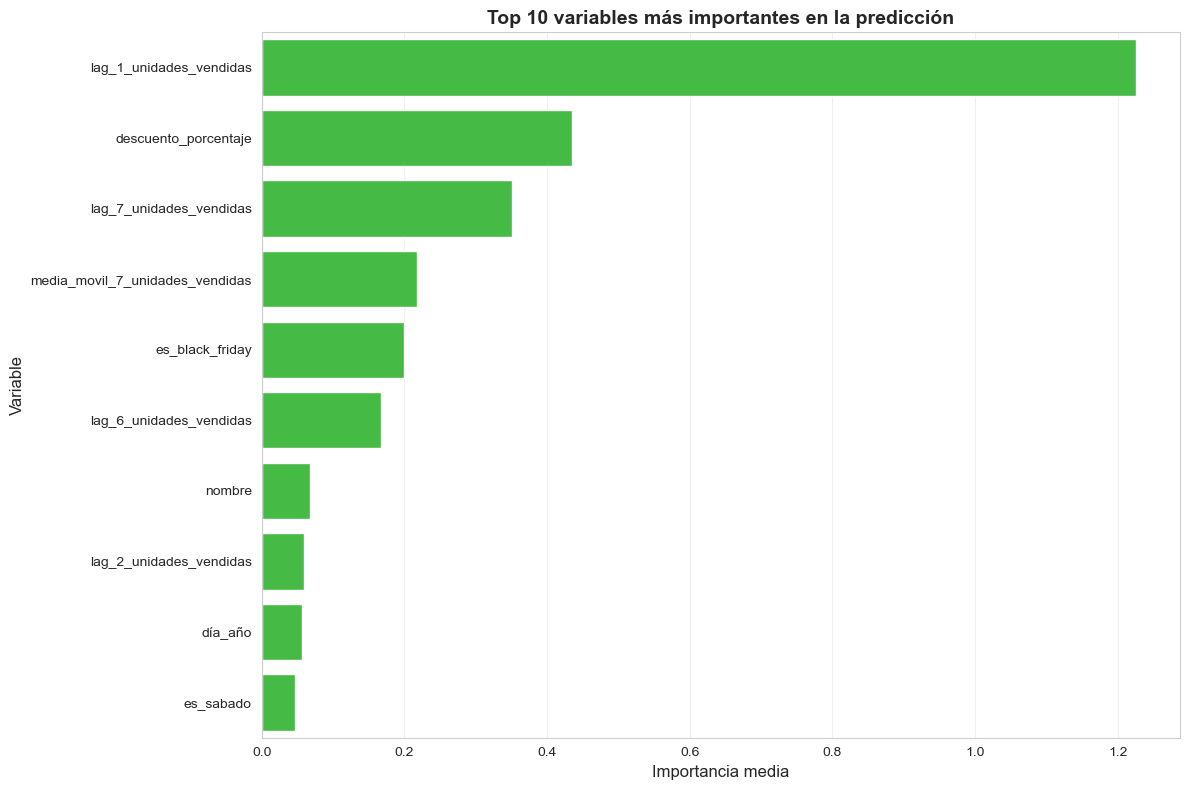

In [41]:
# Gráfico de las 10 variables más importantes
importancias_grafico = (
    importancias.nlargest(10, 'importancia_media')
    .sort_values('importancia_media', ascending=True)
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=importancias_grafico,
    x='importancia_media',
    y='variable',
    order=importancias_grafico['variable'].tolist(),
    color='limegreen'
)
plt.title('Top 10 variables más importantes en la predicción', fontsize=14, fontweight='bold')
plt.xlabel('Importancia media', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Productos estrella encontrados: 7
['Adidas Ultraboost 23', 'Bowflex SelectTech 552', 'Domyos BM900', 'Manduka PRO Yoga Mat', 'Nike Air Zoom Pegasus 40', 'Salomon Speedcross 5 GTX', 'Trek Marlin 7']


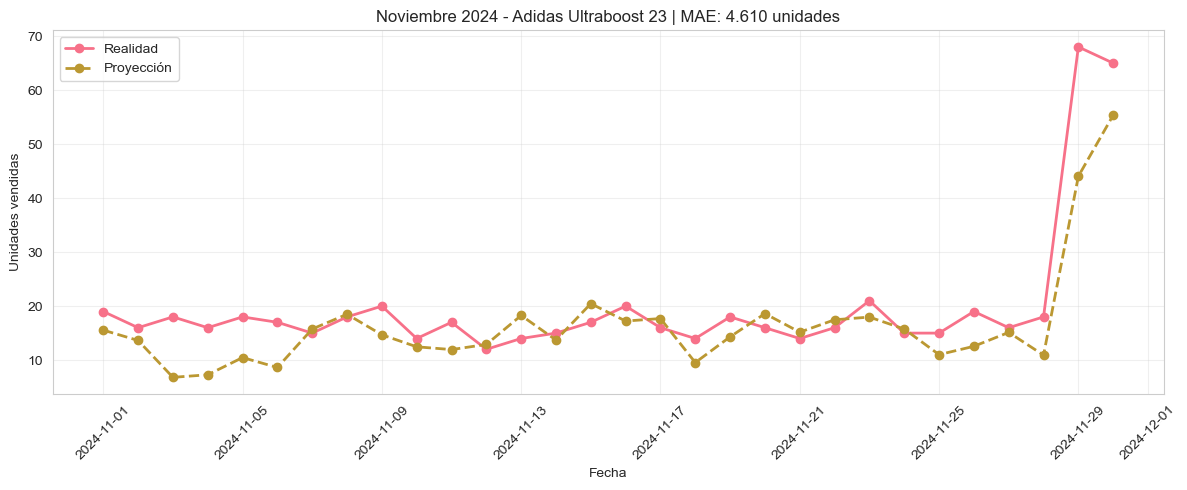

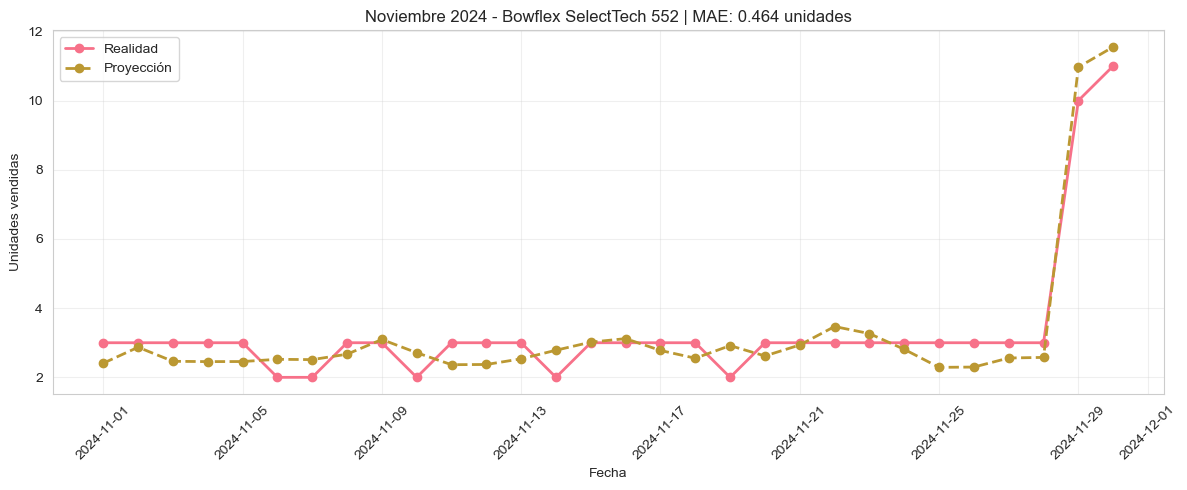

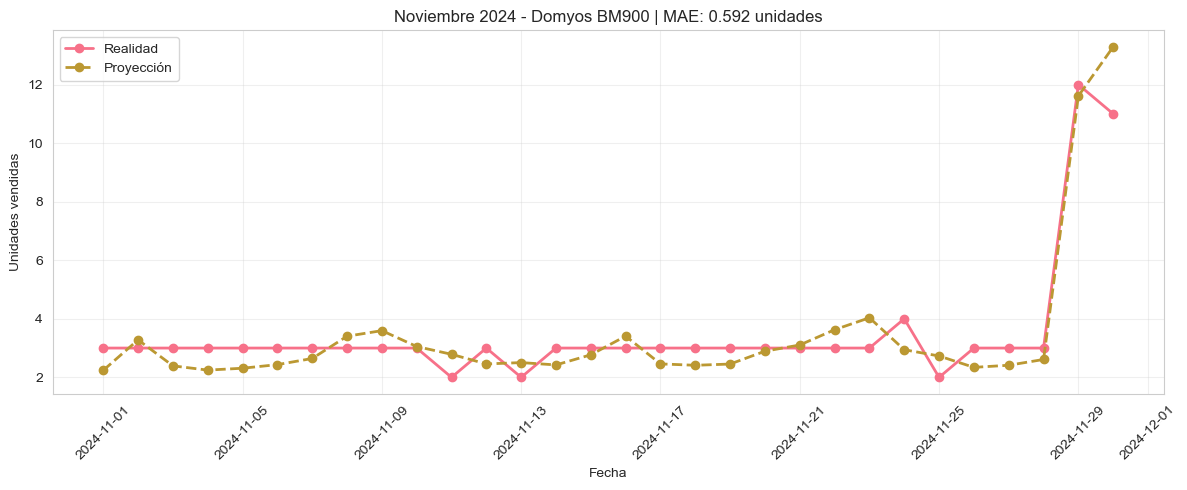

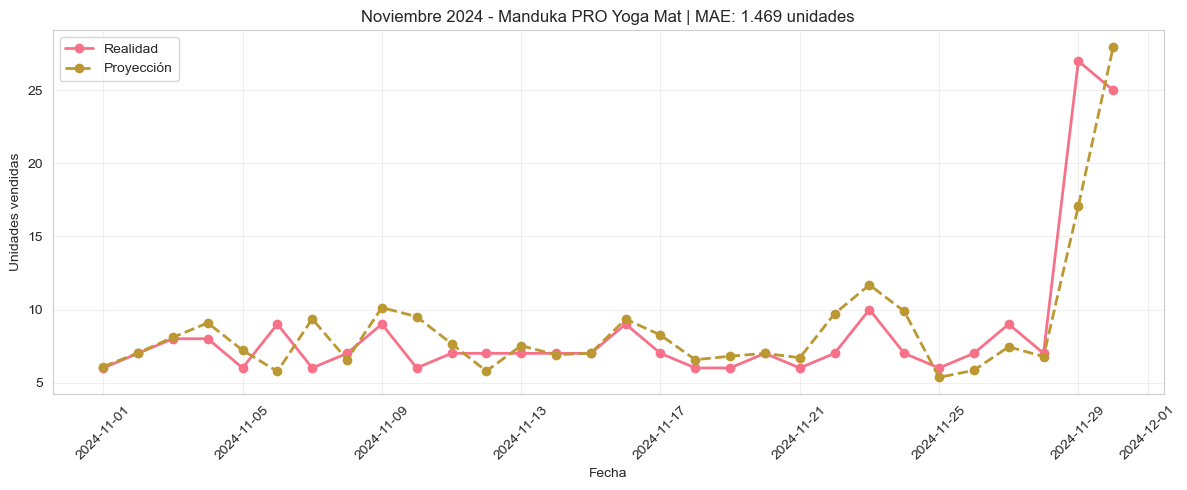

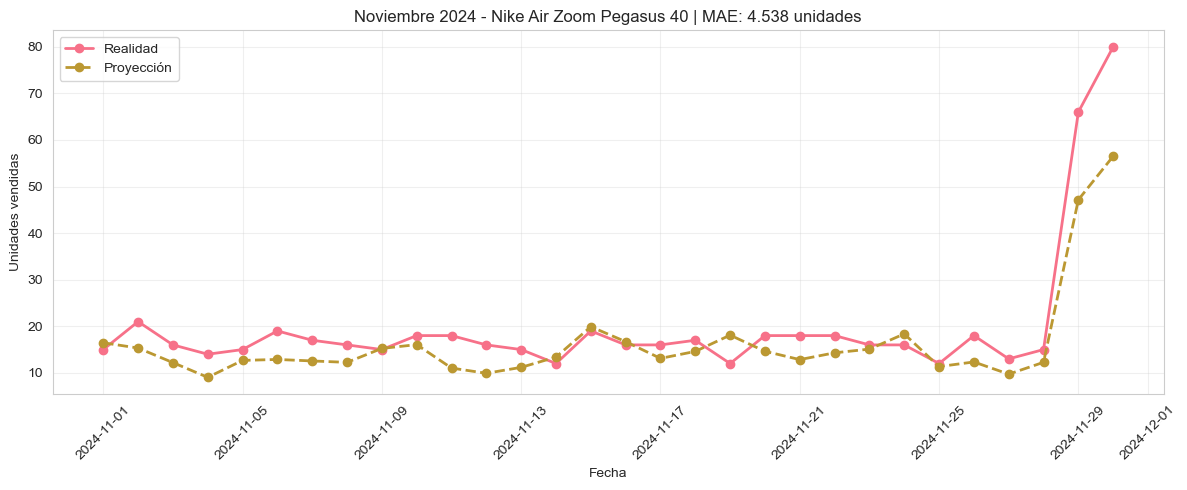

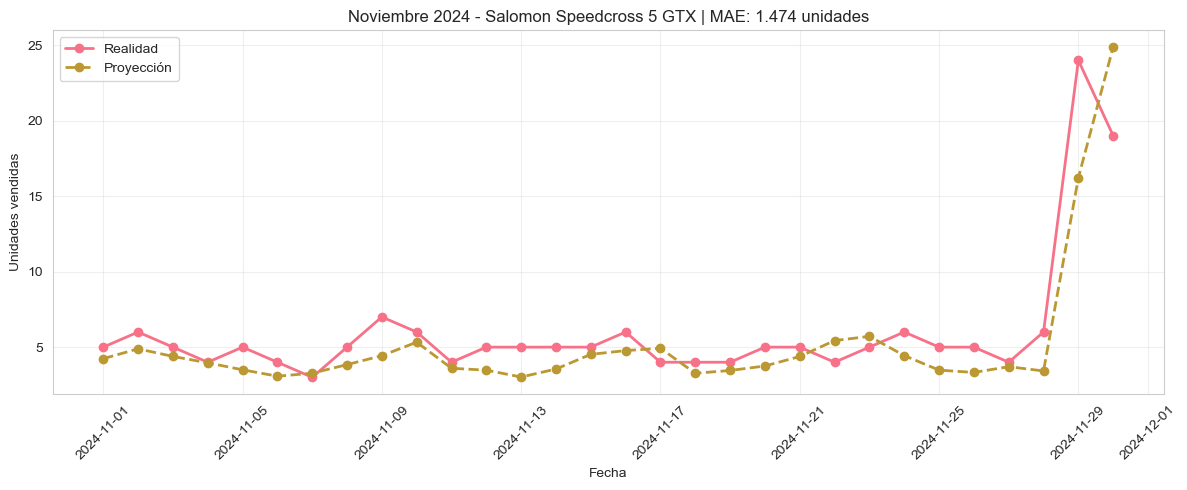

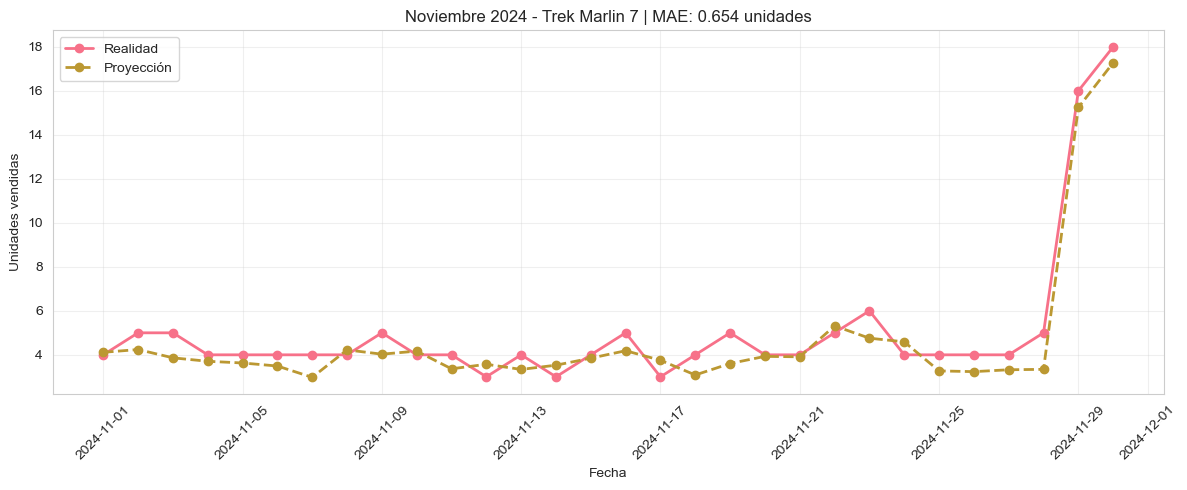

In [42]:
# Predicciones y gráficos para los 7 productos estrella de noviembre de 2024
noviembre_2024 = validation_df[
    pd.to_datetime(validation_df['fecha']).dt.to_period('M') == pd.Period('2024-11')
].copy()

productos_estrella = sorted(
    noviembre_2024.loc[
        noviembre_2024['es_estrella'].astype(bool), 'nombre'
    ].dropna().unique()
)

if len(productos_estrella) != 7:
    raise ValueError(
        f"Se esperaban 7 productos estrella y se encontraron {len(productos_estrella)}: "
        f"{productos_estrella}"
    )

noviembre_2024['proyeccion'] = modelo_final.predict(
    noviembre_2024[predictor_vars]
)

print(f"Productos estrella encontrados: {len(productos_estrella)}")
print(productos_estrella)

for nombre_producto in productos_estrella:
    datos_producto = noviembre_2024[
        noviembre_2024['nombre'] == nombre_producto
    ].sort_values('fecha')

    mae_producto = mean_absolute_error(
        datos_producto['unidades_vendidas'],
        datos_producto['proyeccion']
    )

    plt.figure(figsize=(12, 5))
    plt.plot(
        datos_producto['fecha'],
        datos_producto['unidades_vendidas'],
        marker='o',
        linewidth=2,
        label='Realidad'
    )
    plt.plot(
        datos_producto['fecha'],
        datos_producto['proyeccion'],
        marker='o',
        linewidth=2,
        linestyle='--',
        label='Proyección'
    )
    plt.title(
        f"Noviembre 2024 - {nombre_producto} | MAE: {mae_producto:.3f} unidades"
    )
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [43]:
# MAE por producto estrella en noviembre de 2024
mae_productos_estrella = []

for nombre_producto in productos_estrella:
    datos_producto = noviembre_2024[
        noviembre_2024['nombre'] == nombre_producto
    ]
    mae_producto = mean_absolute_error(
        datos_producto['unidades_vendidas'],
        datos_producto['proyeccion']
    )
    mae_productos_estrella.append({
        'producto': nombre_producto,
        'MAE': mae_producto
    })

mae_productos_estrella = pd.DataFrame(mae_productos_estrella)
mae_productos_estrella = mae_productos_estrella.sort_values('MAE').reset_index(drop=True)
mae_productos_estrella['MAE'] = mae_productos_estrella['MAE'].round(3)

print('MAE por producto estrella - noviembre de 2024')
display(mae_productos_estrella)

MAE por producto estrella - noviembre de 2024


,producto,MAE
0,Bowflex SelectTech 552,0.464
1,Domyos BM900,0.592
2,Trek Marlin 7,0.654
3,Manduka PRO Yoga Mat,1.469
4,Salomon Speedcross 5 GTX,1.474
5,Nike Air Zoom Pegasus 40,4.538
6,Adidas Ultraboost 23,4.610


Métricas de error por periodo - productos estrella - noviembre de 2024


,periodo,MAE,RMSE,MAPE (%)
0,Días 1-10,1.763,2.910,19.303
1,Días 11-20,1.382,2.086,17.793
2,Días 21-30,2.770,5.418,19.078


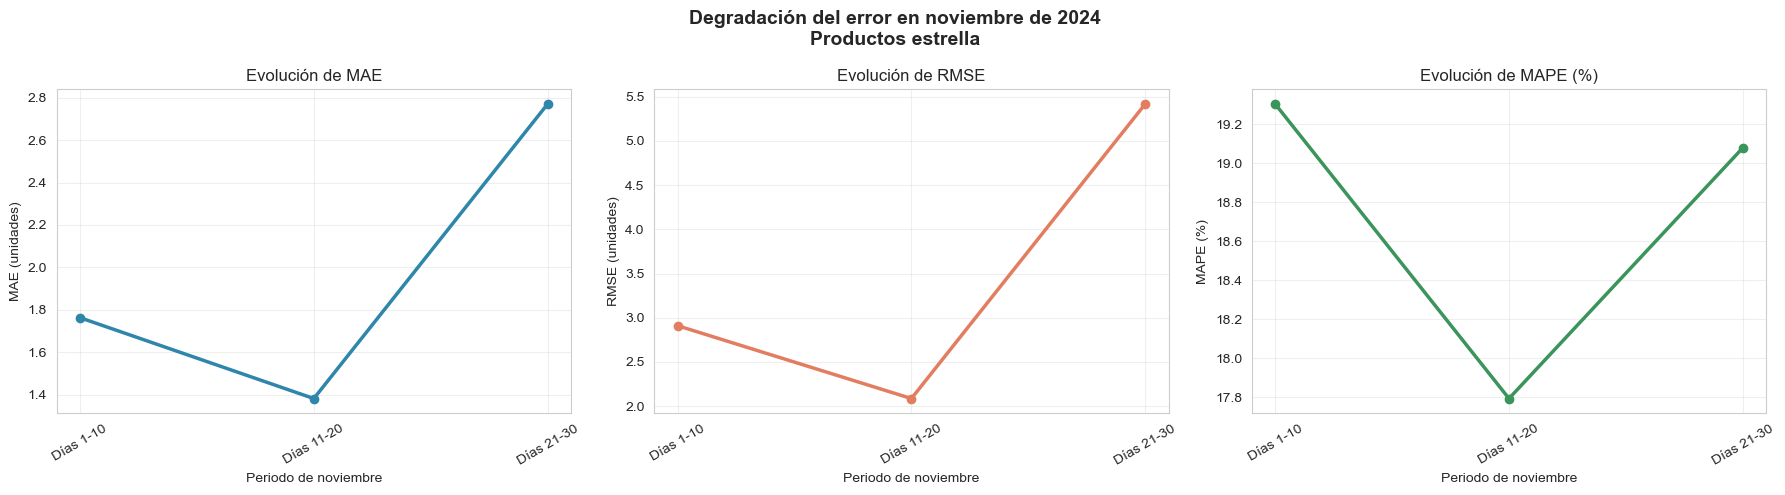

In [44]:
# Evolución del error en noviembre de 2024 por periodos de 10 días
noviembre_2024_estrella = noviembre_2024[
    noviembre_2024['nombre'].isin(productos_estrella)
].copy()
noviembre_2024_estrella['día_mes'] = pd.to_datetime(
    noviembre_2024_estrella['fecha']
).dt.day

periodos_noviembre = ['Días 1-10', 'Días 11-20', 'Días 21-30']
noviembre_2024_estrella['periodo'] = pd.cut(
    noviembre_2024_estrella['día_mes'],
    bins=[0, 10, 20, 31],
    labels=periodos_noviembre,
    right=True
)

metricas_periodo = []

for periodo in periodos_noviembre:
    datos_periodo = noviembre_2024_estrella[
        noviembre_2024_estrella['periodo'] == periodo
    ]
    valores_reales = datos_periodo['unidades_vendidas']
    valores_proyectados = datos_periodo['proyeccion']
    valores_no_cero = valores_reales != 0

    metricas_periodo.append({
        'periodo': periodo,
        'MAE': mean_absolute_error(valores_reales, valores_proyectados),
        'RMSE': np.sqrt(mean_squared_error(valores_reales, valores_proyectados)),
        'MAPE (%)': (
            np.abs(
                (valores_reales[valores_no_cero] - valores_proyectados[valores_no_cero])
                / valores_reales[valores_no_cero]
            ).mean() * 100
        )
    })

metricas_periodo = pd.DataFrame(metricas_periodo)
metricas_periodo[['MAE', 'RMSE', 'MAPE (%)']] = metricas_periodo[
    ['MAE', 'RMSE', 'MAPE (%)']
].round(3)

print('Métricas de error por periodo - productos estrella - noviembre de 2024')
display(metricas_periodo)

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))
metricas_grafico = [
    ('MAE', 'MAE (unidades)', '#2E86AB'),
    ('RMSE', 'RMSE (unidades)', '#E27D60'),
    ('MAPE (%)', 'MAPE (%)', '#3A945B')
]

for eje, (metrica, etiqueta, color) in zip(ejes, metricas_grafico):
    eje.plot(
        metricas_periodo['periodo'],
        metricas_periodo[metrica],
        marker='o',
        linewidth=2.5,
        color=color
    )
    eje.set_title(f'Evolución de {metrica}')
    eje.set_xlabel('Periodo de noviembre')
    eje.set_ylabel(etiqueta)
    eje.grid(alpha=0.3)
    eje.tick_params(axis='x', rotation=30)

fig.suptitle(
    'Degradación del error en noviembre de 2024\n'
    'Productos estrella',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

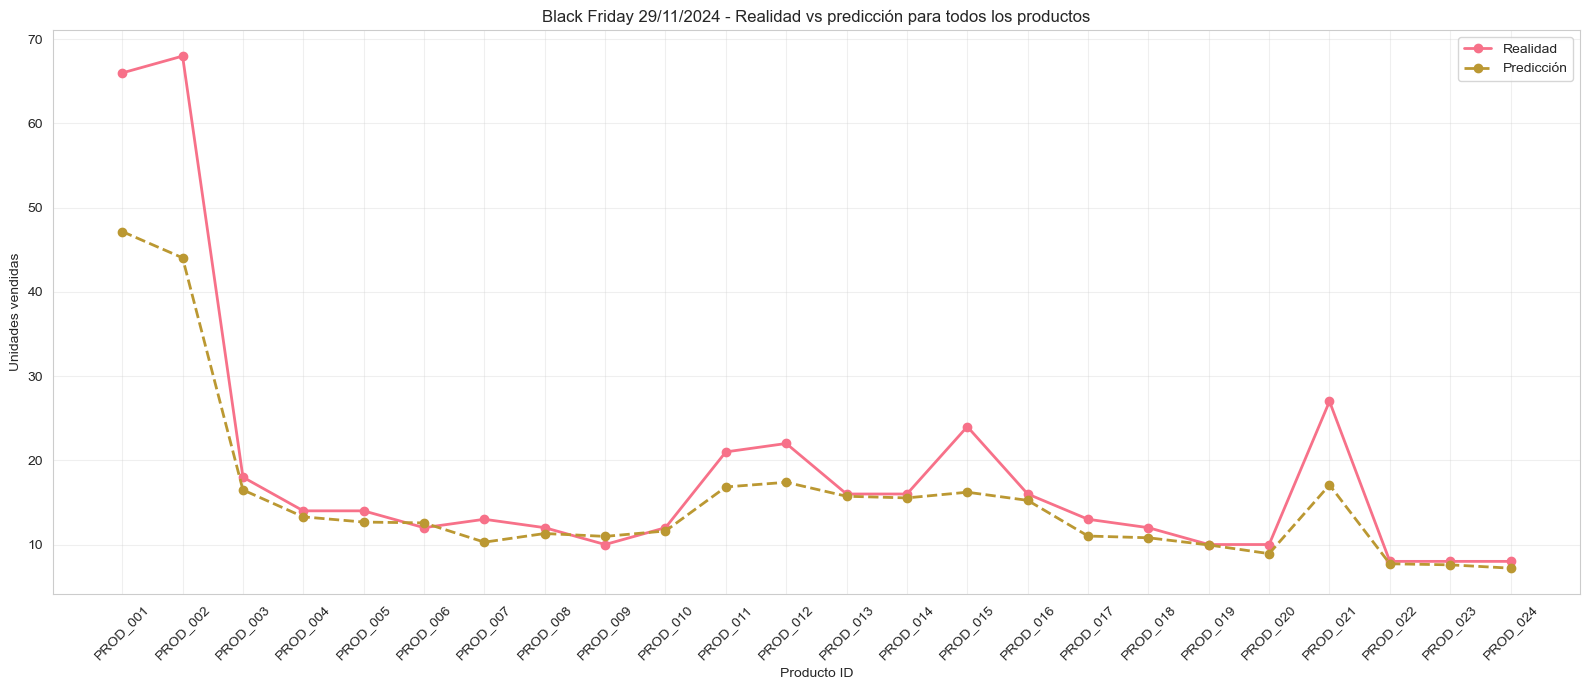

Fecha analizada: 29/11/2024 | Productos incluidos: 24


In [45]:
# Análisis de Black Friday 2024 para todos los productos
fecha_black_friday_2024 = [
    fecha for fecha in black_friday_dates if fecha.year == 2024
][0]

black_friday_2024 = noviembre_2024[
    pd.to_datetime(noviembre_2024['fecha']) == fecha_black_friday_2024
].copy()

black_friday_2024 = black_friday_2024.sort_values('producto_id')

if black_friday_2024.empty:
    raise ValueError(
        f'No hay datos para Black Friday 2024 ({fecha_black_friday_2024.date()}).'
    )

plt.figure(figsize=(16, 7))
plt.plot(
    black_friday_2024['producto_id'].astype(str),
    black_friday_2024['unidades_vendidas'],
    marker='o',
    linewidth=2,
    label='Realidad'
)
plt.plot(
    black_friday_2024['producto_id'].astype(str),
    black_friday_2024['proyeccion'],
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Predicción'
)
plt.title(
    f'Black Friday {fecha_black_friday_2024.strftime("%d/%m/%Y")} - '
    'Realidad vs predicción para todos los productos'
)
plt.xlabel('Producto ID')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(
    f'Fecha analizada: {fecha_black_friday_2024.strftime("%d/%m/%Y")} | '
    f'Productos incluidos: {black_friday_2024["producto_id"].nunique()}'
)

In [46]:
# Guardar el modelo final
import joblib

ruta_modelo = '../models/modelo_final.joblib'
ruta_predictor_vars = '../models/predictor_vars.joblib' 

joblib.dump(modelo_final, ruta_modelo)
joblib.dump(predictor_vars, ruta_predictor_vars)

print(f'Modelo guardado correctamente en: {ruta_modelo}')
print(f'Variables predictoras guardadas correctamente en: {ruta_predictor_vars}')

Modelo guardado correctamente en: ../models/modelo_final.joblib
Variables predictoras guardadas correctamente en: ../models/predictor_vars.joblib
